# Drug Repurposing Pathfinding Algorithm Benchmark

**Purpose:** Evaluate graph pathfinding algorithms for drug repurposing by comparing predicted mechanistic pathways against curated ground truth pathways.



---

## Setup


In [33]:
# Standard libraries
import os
import sys
import time
import heapq
import warnings
import importlib
from pathlib import Path
from difflib import SequenceMatcher
from typing import Dict, List, Tuple
from collections import deque, Counter

# Data / graph / math
import pandas as pd
import numpy as np
import networkx as nx
from scipy import stats

# Visualization
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Project modules
from evaluation_helpers import *
from evaluation_metrics import *
import Algorithms
importlib.reload(Algorithms)
from evaluation_runner import run_evaluation
import evaluation_visualization as ev


from collections import Counter
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde

warnings.filterwarnings('ignore')
importlib.reload(ev)

✓ Evaluation visualization loaded
  Use: generate_full_report(summary)
  Or:  display_summary_table(summary)


<module 'evaluation_visualization' from '/Users/maxchiu/Desktop/primekg_newversion/PrimeKG-Pathfinding-Algorithm-Benchmark-Laboratory/notebook/evaluation_visualization.py'>

In [31]:

# Detect repository root (folder that contains "data")
REPO_ROOT = Path.cwd()

# If running from /notebook, move up one level
if not (REPO_ROOT / "data").exists() and (REPO_ROOT.parent / "data").exists():
    REPO_ROOT = REPO_ROOT.parent

DATA_DIR = REPO_ROOT / "data"

PATHS = {
    "nodes": DATA_DIR / "nodes.csv",
    "edges": DATA_DIR / "edges.csv",
    "ground_truth_nodes": DATA_DIR / "benchmark_pathways_nodes.csv",
    "ground_truth_edges": DATA_DIR / "benchmark_pathways_edges.csv",
}

print("Repo root:", REPO_ROOT)
for k, p in PATHS.items():
    print(f"{k}: {p} | exists={p.exists()}")

Repo root: /Users/johncollins/Desktop/PrimeKG-Pathfinding-Algorithm-Benchmark-Laboratory
nodes: /Users/johncollins/Desktop/PrimeKG-Pathfinding-Algorithm-Benchmark-Laboratory/data/nodes.csv | exists=True
edges: /Users/johncollins/Desktop/PrimeKG-Pathfinding-Algorithm-Benchmark-Laboratory/data/edges.csv | exists=True
ground_truth_nodes: /Users/johncollins/Desktop/PrimeKG-Pathfinding-Algorithm-Benchmark-Laboratory/data/benchmark_pathways_nodes.csv | exists=True
ground_truth_edges: /Users/johncollins/Desktop/PrimeKG-Pathfinding-Algorithm-Benchmark-Laboratory/data/benchmark_pathways_edges.csv | exists=True


---
## Load Data

Load the PrimeKG knowledge graph and ground truth pathways.

In [4]:
# Load PrimeKG data
print("Loading PrimeKG data...")
nodes = pd.read_csv(PATHS['nodes'], encoding="latin1")
edges = pd.read_csv(PATHS['edges'], encoding="latin1")

print(f"  Nodes: {len(nodes):,}")
print(f"  Edges: {len(edges):,}")
print(f"  Node types: {nodes['node_type'].nunique()}")
print(f"  Edge types: {edges['relation'].nunique()}")

# Load ground truth
print("\nLoading ground truth pathways...")
ground_truth_nodes = pd.read_csv(PATHS['ground_truth_nodes'], dtype={'node_index': int})
ground_truth_edges = pd.read_csv(PATHS['ground_truth_edges'])

pathways = ground_truth_nodes['pathway_id'].unique()
print(f"  Pathways: {len(pathways)}")
for p in pathways:
    n_nodes = len(ground_truth_nodes[ground_truth_nodes['pathway_id'] == p])
    print(f"    - {p}: {n_nodes} nodes")

Loading PrimeKG data...
  Nodes: 129,375
  Edges: 8,100,498
  Node types: 10
  Edge types: 30

Loading ground truth pathways...
  Pathways: 343
    - valganciclovir_CMV_infection: 3 nodes
    - antazoline_Vasomotor_rhinitis: 3 nodes
    - apalutamide_Nonmetastatic_prostate_cancer: 3 nodes
    - aminoglutethimide_Secondary_malignant_neoplasm_o: 3 nodes
    - anastrozole_Hormone_receptor_positive_mali: 3 nodes
    - diflunisal_Rheumatoid_arthritis: 5 nodes
    - mepyramine_Vasomotor_rhinitis: 3 nodes
    - azilsartan_medoxomil_Hypertensive_disorder: 3 nodes
    - bromocriptine_Hyperprolactinemia: 5 nodes
    - amobarbital_Epilepsy: 6 nodes
    - terbutaline_Asthma: 3 nodes
    - tafamidis_Amyloidosis: 3 nodes
    - FYX-051_Hyperuricemia: 3 nodes
    - FYX-051_Gout: 3 nodes
    - glimepiride_Diabetes_mellitus_type_2: 3 nodes
    - capecitabine_Malignant_tumor_of_stomach: 4 nodes
    - oxaprozin_Rheumatoid_arthritis: 5 nodes
    - pimozide_Gilles_de_la_Tourette's_syndro: 3 nodes
    - clem

In [5]:
# filter
node_counts = ground_truth_nodes.groupby('pathway_id')['node_index'].count()
long_pathways = node_counts[node_counts >= 4].index

ground_truth_nodes = ground_truth_nodes[ground_truth_nodes['pathway_id'].isin(long_pathways)]
ground_truth_edges = ground_truth_edges[ground_truth_edges['pathway_id'].isin(long_pathways)]

print(f"Filtered to {len(long_pathways)} pathways with 4+ nodes")
print(f"  Nodes: {len(ground_truth_nodes):,}")
print(f"  Edges: {len(ground_truth_edges):,}")

Filtered to 150 pathways with 4+ nodes
  Nodes: 877
  Edges: 727


---
## Build Knowledge Graph

Construct a NetworkX directed graph with node/edge attributes for pathfinding.

In [6]:
def build_graph(nodes_df, edges_df, bidirectional=True):
    """
    Build a NetworkX graph from cleaned PrimeKG CSVs.
    
    nodes_df columns:
        node_index, node_id, node_type, node_name, node_source
        
    edges_df columns:
        relation, display_relation, x_index, y_index
    """
    
    G = nx.DiGraph()
    
    # ---------- Add nodes ----------
    for _, row in nodes_df.iterrows():
        G.add_node(
            int(row['node_index']),
            node_id=str(row['node_id']),
            node_name=str(row['node_name']),
            node_type=str(row['node_type']),
            node_source=str(row['node_source'])
        )
    
    # ---------- Add edges ----------
    for _, row in edges_df.iterrows():
        G.add_edge(
            int(row['x_index']),
            int(row['y_index']),
            relation=str(row['relation']),
            display_relation=str(row['display_relation'])
        )
        
        if bidirectional:
            G.add_edge(
                int(row['y_index']),
                int(row['x_index']),
                relation=str(row['relation']),
                display_relation=str(row['display_relation'])
            )
    
    return G

print("Building graph...")
G = build_graph(nodes, edges, bidirectional=True)
print(f"Graph built: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

Building graph...
Graph built: 129,375 nodes, 8,099,284 edges


---
## Algorithm 1 - Shortest Path Baseline

The simplest baseline: find the shortest path (by hop count) between drug and disease.

**Expected behavior:**
- ✅ Will always find the target disease (if connected)
- ❌ May take shortcuts through direct drug→disease edges
- ❌ Ignores edge types and biological mechanism

In [7]:
def run_shortest_path(graph, ground_truth_df):
    """
    Run shortest path algorithm on all pathways.
    
    Returns:
        DataFrame with predictions for each pathway
    """
    results = []
    
    for pathway_id in ground_truth_df['pathway_id'].unique():
        pathway_df = ground_truth_df[ground_truth_df['pathway_id'] == pathway_id].sort_values('step_order')
        
        # Get source (drug) and target (disease) indices
        source_idx = int(pathway_df.iloc[0]['node_index'])
        target_idx = int(pathway_df.iloc[-1]['node_index'])
        
        source_name = pathway_df.iloc[0]['node_name']
        target_name = pathway_df.iloc[-1]['node_name']
        
        print(f"\n{pathway_id}: {source_name} → {target_name}")
        
        try:
            # Find shortest path
            predicted_path = nx.shortest_path(graph, source_idx, target_idx)
            predicted_node_ids = [graph.nodes[idx]['node_id'] for idx in predicted_path]
            predicted_node_names = [graph.nodes[idx]['node_name'] for idx in predicted_path]
            
            # Get edge relations along path
            predicted_relations = []
            for i in range(len(predicted_path) - 1):
                edge_data = graph.get_edge_data(predicted_path[i], predicted_path[i+1])
                predicted_relations.append(edge_data['relation'])
            
            print(f"  ✓ Found path: {len(predicted_path)} nodes")
            print(f"  Path: {' → '.join(predicted_node_names[:5])}{'...' if len(predicted_path) > 5 else ''}")
            
            results.append({
                'pathway_id': pathway_id,
                'predicted_node_indices': ','.join(map(str, predicted_path)),
                'predicted_node_ids': ','.join(predicted_node_ids),
                'predicted_node_names': ','.join(predicted_node_names),
                'predicted_relations': ','.join(predicted_relations),
                'predicted_length': len(predicted_path),
                'ground_truth_length': len(pathway_df)
            })
            
        except nx.NetworkXNoPath:
            print(f"  ✗ No path found")
            results.append({
                'pathway_id': pathway_id,
                'predicted_node_indices': 'NONE',
                'predicted_node_ids': 'NONE',
                'predicted_node_names': 'NONE',
                'predicted_relations': 'NONE',
                'predicted_length': 0,
                'ground_truth_length': len(pathway_df)
            })
    
    return pd.DataFrame(results)


# Run shortest path
print("="*60)
print("Running Shortest Path Algorithm")
print("="*60)

sp_predictions = run_shortest_path(G, ground_truth_nodes)

Running Shortest Path Algorithm

diflunisal_Rheumatoid_arthritis: diflunisal → Rheumatoid arthritis
  ✓ Found path: 2 nodes
  Path: Diflunisal → rheumatoid arthritis

bromocriptine_Hyperprolactinemia: bromocriptine → Hyperprolactinemia
  ✓ Found path: 2 nodes
  Path: Bromocriptine → hyperprolactinemia (disease)

amobarbital_Epilepsy: amobarbital → Epilepsy
  ✓ Found path: 2 nodes
  Path: Amobarbital → epilepsy

capecitabine_Malignant_tumor_of_stomach: Capecitabine → Malignant tumor of stomach
  ✓ Found path: 2 nodes
  Path: Capecitabine → gastric neoplasm

oxaprozin_Rheumatoid_arthritis: oxaprozin → Rheumatoid arthritis
  ✓ Found path: 2 nodes
  Path: Oxaprozin → rheumatoid arthritis

regorafenib_Gastrointestinal_stromal_tumor: regorafenib → Gastrointestinal stromal tumor
  ✓ Found path: 2 nodes
  Path: Regorafenib → gastrointestinal stromal tumor

abiraterone_acetate_Malignant_tumor_of_prostate: abiraterone acetate → Malignant tumor of prostate
  ✓ Found path: 3 nodes
  Path: Abirater

---
## Meta-Path Constrained BFS

An improved baseline that enforces biologically valid edge type sequences.

**Valid meta-path patterns:**
1. `drug → protein → disease` (direct mechanism)
2. `drug → protein → protein → disease` (protein interactions)
3. `drug → protein → anatomy → protein → disease` (tissue-specific)

**Invalid shortcuts blocked:**
- ❌ `drug → disease` (clinical indication, not mechanism)
- ❌ `drug → drug → disease` (drug similarity)

In [8]:
# Define valid meta-path patterns (edge type sequences)
VALID_METAPATHS = [
    # Pattern 1: Direct protein mechanism (drug → protein → disease)
    ['drug_protein', 'disease_protein'],
    
    # Pattern 2: Protein-protein interaction
    ['drug_protein', 'protein_protein', 'disease_protein'],
    
    # Pattern 3: Multiple protein interactions
    ['drug_protein', 'protein_protein', 'protein_protein', 'disease_protein'],
    
    # Pattern 4: Pathway-mediated
    ['drug_protein', 'pathway_protein', 'disease_protein'],
    ['drug_protein', 'pathway_protein', 'pathway_protein', 'disease_protein'],
    ['drug_protein', 'pathway_protein', 'pathway_pathway', 'pathway_protein', 'disease_protein'],
    
    # Pattern 5: Anatomy-mediated (tissue-specific)
    ['drug_protein', 'anatomy_protein_present', 'anatomy_protein_present', 'disease_protein'],
    
    # Pattern 6: Complex pathways
    ['drug_protein', 'protein_protein', 'pathway_protein', 'disease_protein'],
    ['drug_protein', 'pathway_protein', 'pathway_protein', 'pathway_protein', 'disease_protein'],
]

print(f"Defined {len(VALID_METAPATHS)} valid meta-path patterns:")
for i, pattern in enumerate(VALID_METAPATHS, 1):
    print(f"  {i}. {' → '.join(pattern)}")

Defined 9 valid meta-path patterns:
  1. drug_protein → disease_protein
  2. drug_protein → protein_protein → disease_protein
  3. drug_protein → protein_protein → protein_protein → disease_protein
  4. drug_protein → pathway_protein → disease_protein
  5. drug_protein → pathway_protein → pathway_protein → disease_protein
  6. drug_protein → pathway_protein → pathway_pathway → pathway_protein → disease_protein
  7. drug_protein → anatomy_protein_present → anatomy_protein_present → disease_protein
  8. drug_protein → protein_protein → pathway_protein → disease_protein
  9. drug_protein → pathway_protein → pathway_protein → pathway_protein → disease_protein


In [9]:
def is_valid_metapath(relations, valid_metapaths):
    """Check if a relation sequence matches any valid meta-path pattern."""
    return relations in valid_metapaths


def could_match_metapath(relations, valid_metapaths):
    """Check if the current relation sequence could potentially lead to a valid path."""
    for pattern in valid_metapaths:
        if len(relations) <= len(pattern):
            if relations == pattern[:len(relations)]:
                return True
    return False


def metapath_constrained_bfs(source_idx, target_idx, graph, valid_metapaths, max_length=10):
    """
    Find shortest path that follows valid meta-path patterns.
    
    Uses BFS but only explores edges that could lead to a valid meta-path.
    
    Returns:
        (path_nodes, path_relations) or ([], []) if no valid path found
    """
    # Queue: (current_node, path_so_far, relations_so_far)
    queue = deque([(source_idx, [source_idx], [])])
    visited = {source_idx: []}  # Track visited states with relation sequences
    
    while queue:
        current_node, path, relations = queue.popleft()
        
        # Check if we reached target with valid meta-path
        if current_node == target_idx:
            if is_valid_metapath(relations, valid_metapaths):
                return path, relations
        
        # Stop if path too long
        if len(path) >= max_length:
            continue
        
        # Explore neighbors
        for neighbor in graph.neighbors(current_node):
            edge_data = graph.get_edge_data(current_node, neighbor)
            new_relation = edge_data['relation']
            new_relations = relations + [new_relation]
            
            # Only continue if this could lead to a valid meta-path
            if could_match_metapath(new_relations, valid_metapaths):
                state_key = (neighbor, tuple(new_relations))
                
                # Avoid revisiting same state
                if neighbor not in visited or visited[neighbor] != new_relations:
                    visited[neighbor] = new_relations
                    queue.append((neighbor, path + [neighbor], new_relations))
    
    return [], []  # No valid path found


def run_metapath_algorithm(graph, ground_truth_df, valid_metapaths):
    """
    Run meta-path constrained BFS on all pathways.
    """
    results = []
    
    for pathway_id in ground_truth_df['pathway_id'].unique():
        pathway_df = ground_truth_df[ground_truth_df['pathway_id'] == pathway_id].sort_values('step_order')
        
        source_idx = int(pathway_df.iloc[0]['node_index'])
        target_idx = int(pathway_df.iloc[-1]['node_index'])
        
        source_name = pathway_df.iloc[0]['node_name']
        target_name = pathway_df.iloc[-1]['node_name']
        
        gt_path = ' → '.join(pathway_df['node_name'].tolist())
        
        print(f"\n{pathway_id}: {source_name} → {target_name}")
        
        # Find meta-path constrained path
        predicted_path, predicted_relations = metapath_constrained_bfs(
            source_idx, target_idx, graph, valid_metapaths
        )
        
        if predicted_path:
            predicted_node_ids = [graph.nodes[idx]['node_id'] for idx in predicted_path]
            predicted_node_names = [graph.nodes[idx]['node_name'] for idx in predicted_path]
            
            print(f"  ✓ Found valid path: {len(predicted_path)} nodes")
            print(f"  Meta-path: {' → '.join(predicted_relations)}")
            print(f"  Path: {' → '.join(predicted_node_names)}")
            print(f"  Ground truth: {gt_path}")
            
            results.append({
                'pathway_id': pathway_id,
                'predicted_node_indices': ','.join(map(str, predicted_path)),
                'predicted_node_ids': ','.join(predicted_node_ids),
                'predicted_node_names': ','.join(predicted_node_names),
                'predicted_relations': ','.join(predicted_relations),
                'predicted_length': len(predicted_path),
                'ground_truth_length': len(pathway_df)
            })
        else:
            print(f"  ✗ No valid meta-path found")
            results.append({
                'pathway_id': pathway_id,
                'predicted_node_indices': 'NONE',
                'predicted_node_ids': 'NONE',
                'predicted_node_names': 'NONE',
                'predicted_relations': 'NONE',
                'predicted_length': 0,
                'ground_truth_length': len(pathway_df)
            })
    
    return pd.DataFrame(results)


# Run meta-path algorithm
print("="*60)
print("Running Meta-Path Constrained Algorithm")
print("="*60)

mp_predictions = run_metapath_algorithm(G, ground_truth_nodes, VALID_METAPATHS)
# mp_predictions.to_csv('baseline_metapath_predictions.csv', index=False)
# print("\n✓ Saved: baseline_metapath_predictions.csv")

Running Meta-Path Constrained Algorithm

diflunisal_Rheumatoid_arthritis: diflunisal → Rheumatoid arthritis
  ✓ Found valid path: 3 nodes
  Meta-path: drug_protein → disease_protein
  Path: Diflunisal → PTGS1 → rheumatoid arthritis
  Ground truth: diflunisal → Prostaglandin G/H synthase 2 → inflammatory response → Prostaglandin G/H synthase 1 → Rheumatoid arthritis

bromocriptine_Hyperprolactinemia: bromocriptine → Hyperprolactinemia
  ✓ Found valid path: 3 nodes
  Meta-path: drug_protein → disease_protein
  Path: Bromocriptine → DRD2 → hyperprolactinemia (disease)
  Ground truth: bromocriptine → Dopamine D3 receptor → dopamine → Dopamine D2 receptor → Hyperprolactinemia

amobarbital_Epilepsy: amobarbital → Epilepsy
  ✓ Found valid path: 3 nodes
  Meta-path: drug_protein → disease_protein
  Path: Amobarbital → GABRA5 → epilepsy
  Ground truth: amobarbital → Gamma-aminobutyric acid receptor subunit alpha-2 → GABA-gated chloride ion channel activity → Gamma-aminobutyric acid receptor sub

## Algorithm 2: Hub-Penalized Weighted Shortest Path

**Core Idea:** High-degree "hub" nodes (like inflammation markers) connect to everything but don't represent specific mechanisms. Penalize them.

**Weight Formula:** `weight[u,v] = 1 + α * log(degree[v])`

- α = 0.5 is a good default (can be tuned)
- Higher degree → higher weight → less preferred

In [10]:
# ============================================================
# ALGORITHM 2: Hub-Penalized Weighted Shortest Path
# ============================================================


def run_hub_penalized(graph, ground_truth_df, alpha=0.5):
    """
    Run Hub-Penalized algorithm on all pathways.
    """
    results = []
    
    # Initialize algorithm
    print("Initializing Hub-Penalized algorithm...")
    algo = HubPenalizedShortestPath(graph, alpha=alpha)
    print(f"  Edge weights computed (α={alpha})")
    
    for pathway_id in ground_truth_df['pathway_id'].unique():
        pathway_df = ground_truth_df[ground_truth_df['pathway_id'] == pathway_id].sort_values('step_order')
        
        source_idx = int(pathway_df.iloc[0]['node_index'])
        target_idx = int(pathway_df.iloc[-1]['node_index'])
        source_name = pathway_df.iloc[0]['node_name']
        target_name = pathway_df.iloc[-1]['node_name']
        
        print(f"\n{pathway_id}: {source_name} → {target_name}")
        
        path, relations, weight = algo.find_path(source_idx, target_idx)
        
        if path:
            node_ids = [graph.nodes[idx].get('node_id', str(idx)) for idx in path]
            node_names = [graph.nodes[idx].get('node_name', str(idx)) for idx in path]
            
            print(f"  ✓ Found path: {len(path)} nodes")
            print(f"  Path: {' → '.join(node_names)}")
            
            results.append({
                'pathway_id': pathway_id,
                'predicted_node_indices': ','.join(map(str, path)),
                'predicted_node_ids': ','.join(node_ids),
                'predicted_node_names': ','.join(node_names),
                'predicted_relations': ','.join(relations),
                'predicted_length': len(path),
                'ground_truth_length': len(pathway_df)
            })
        else:
            print(f"  ✗ No path found")
            results.append({
                'pathway_id': pathway_id,
                'predicted_node_indices': 'NONE',
                'predicted_node_ids': 'NONE',
                'predicted_node_names': 'NONE',
                'predicted_relations': 'NONE',
                'predicted_length': 0,
                'ground_truth_length': len(pathway_df)
            })
    
    return pd.DataFrame(results)


# Run Algorithm 2
print("="*60)
print("Running Hub-Penalized Algorithm")
print("="*60)

hub_predictions = run_hub_penalized(G, ground_truth_nodes, alpha=0.5)
# hub_predictions.to_csv('hub_penalized_predictions.csv', index=False)
# print("\n✓ Saved: hub_penalized_predictions.csv")

Running Hub-Penalized Algorithm
Initializing Hub-Penalized algorithm...
  Edge weights computed (α=0.5)

diflunisal_Rheumatoid_arthritis: diflunisal → Rheumatoid arthritis
  ✓ Found path: 3 nodes
  Path: Diflunisal → PTGS1 → rheumatoid arthritis

bromocriptine_Hyperprolactinemia: bromocriptine → Hyperprolactinemia
  ✓ Found path: 3 nodes
  Path: Bromocriptine → DRD2 → hyperprolactinemia (disease)

amobarbital_Epilepsy: amobarbital → Epilepsy
  ✓ Found path: 3 nodes
  Path: Amobarbital → CHRNA4 → epilepsy

capecitabine_Malignant_tumor_of_stomach: Capecitabine → Malignant tumor of stomach
  ✓ Found path: 3 nodes
  Path: Capecitabine → TYMP → gastric neoplasm

oxaprozin_Rheumatoid_arthritis: oxaprozin → Rheumatoid arthritis
  ✓ Found path: 3 nodes
  Path: Oxaprozin → Vasculitis → rheumatoid arthritis

regorafenib_Gastrointestinal_stromal_tumor: regorafenib → Gastrointestinal stromal tumor
  ✓ Found path: 3 nodes
  Path: Regorafenib → PDGFRA → gastrointestinal stromal tumor

abiraterone_ac

## Algorithm 3: PageRank-Inverse Weighted Shortest Path

**Core Idea:** PageRank captures global graph centrality. Nodes with HIGH PageRank are generic hubs. We want paths through LOW PageRank (more specific) nodes.

**Weight Formula:** `weight[u,v] = 1 / (1 + pagerank[v])`

- Low PageRank → low weight → preferred
- PageRank is computed once upfront

In [12]:
# ============================================================
# ALGORITHM 3: PageRank-Inverse Weighted Shortest Path
# ============================================================

def run_pagerank_inverse(graph, ground_truth_df, damping=0.85):
    """
    Run PageRank-Inverse algorithm on all pathways.
    """
    results = []
    
    # Initialize algorithm
    print("Initializing PageRank-Inverse algorithm...")
    algo = PageRankInverseShortestPath(graph, damping=damping)
    print(f"  Edge weights computed")
    
    for pathway_id in ground_truth_df['pathway_id'].unique():
        pathway_df = ground_truth_df[ground_truth_df['pathway_id'] == pathway_id].sort_values('step_order')
        
        source_idx = int(pathway_df.iloc[0]['node_index'])
        target_idx = int(pathway_df.iloc[-1]['node_index'])
        source_name = pathway_df.iloc[0]['node_name']
        target_name = pathway_df.iloc[-1]['node_name']
        
        print(f"\n{pathway_id}: {source_name} → {target_name}")
        
        path, relations, weight = algo.find_path(source_idx, target_idx)
        
        if path:
            node_ids = [graph.nodes[idx].get('node_id', str(idx)) for idx in path]
            node_names = [graph.nodes[idx].get('node_name', str(idx)) for idx in path]
            
            print(f"  ✓ Found path: {len(path)} nodes")
            print(f"  Path: {' → '.join(node_names)}")
            
            results.append({
                'pathway_id': pathway_id,
                'predicted_node_indices': ','.join(map(str, path)),
                'predicted_node_ids': ','.join(node_ids),
                'predicted_node_names': ','.join(node_names),
                'predicted_relations': ','.join(relations),
                'predicted_length': len(path),
                'ground_truth_length': len(pathway_df)
            })
        else:
            print(f"  ✗ No path found")
            results.append({
                'pathway_id': pathway_id,
                'predicted_node_indices': 'NONE',
                'predicted_node_ids': 'NONE',
                'predicted_node_names': 'NONE',
                'predicted_relations': 'NONE',
                'predicted_length': 0,
                'ground_truth_length': len(pathway_df)
            })
    
    return pd.DataFrame(results)


# Run Algorithm 3
print("="*60)
print("Running PageRank-Inverse Algorithm")
print("="*60)

pr_predictions = run_pagerank_inverse(G, ground_truth_nodes, damping=0.85)
# pr_predictions.to_csv('pagerank_inverse_predictions.csv', index=False)
# print("\n✓ Saved: pagerank_inverse_predictions.csv")

Running PageRank-Inverse Algorithm
Initializing PageRank-Inverse algorithm...
  Computing PageRank (this may take a minute)...
  PageRank computed for 129,375 nodes
  Edge weights computed

diflunisal_Rheumatoid_arthritis: diflunisal → Rheumatoid arthritis
  ✓ Found path: 3 nodes
  Path: Diflunisal → Fever → rheumatoid arthritis

bromocriptine_Hyperprolactinemia: bromocriptine → Hyperprolactinemia
  ✓ Found path: 3 nodes
  Path: Bromocriptine → DRD2 → hyperprolactinemia (disease)

amobarbital_Epilepsy: amobarbital → Epilepsy
  ✓ Found path: 3 nodes
  Path: Amobarbital → CHRNA7 → epilepsy

capecitabine_Malignant_tumor_of_stomach: Capecitabine → Malignant tumor of stomach
  ✓ Found path: 3 nodes
  Path: Capecitabine → TYMS → gastric neoplasm

oxaprozin_Rheumatoid_arthritis: oxaprozin → Rheumatoid arthritis
  ✓ Found path: 3 nodes
  Path: Oxaprozin → Fever → rheumatoid arthritis

regorafenib_Gastrointestinal_stromal_tumor: regorafenib → Gastrointestinal stromal tumor
  ✓ Found path: 3 nod

## Algorithm 4: Learned Embeddings + A* with Supervised Edge Weights

**Core Idea:** Learn from known drug repurposing pathways what makes a "good" edge.

**Two Phases:**
1. **Embed:** Train Node2Vec (or use spectral embeddings) to capture graph structure
2. **Learn:** Train MLP to predict edge goodness from:
   - Embedding similarity
   - Degree features
   - Edge type

**Search:** A* with learned weights + embedding-based heuristic

In [13]:
# ============================================================
# ALGORITHM 4: Learned Embeddings + A* with Supervised Edge Weights
# ============================================================

def run_learned_astar(graph, ground_truth_df, embedding_dim=64):
    """
    Run Learned Embeddings + A* algorithm on all pathways.
    """
    results = []
    
    # Initialize algorithm
    print("Initializing Learned Embeddings + A* algorithm...")
    algo = LearnedEmbeddingsAStar(graph, embedding_dim=embedding_dim)
    algo.train_embeddings()
    
    # Prepare training data from ground truth
    training_pathways = []
    for pathway_id in ground_truth_df['pathway_id'].unique():
        pathway_df = ground_truth_df[ground_truth_df['pathway_id'] == pathway_id].sort_values('step_order')
        training_pathways.append({'path_nodes': pathway_df['node_index'].tolist()})
    
    algo.train_edge_weights(training_pathways)
    
    for pathway_id in ground_truth_df['pathway_id'].unique():
        pathway_df = ground_truth_df[ground_truth_df['pathway_id'] == pathway_id].sort_values('step_order')
        
        source_idx = int(pathway_df.iloc[0]['node_index'])
        target_idx = int(pathway_df.iloc[-1]['node_index'])
        source_name = pathway_df.iloc[0]['node_name']
        target_name = pathway_df.iloc[-1]['node_name']
        
        print(f"\n{pathway_id}: {source_name} → {target_name}")
        
        path, relations, weight = algo.find_path(source_idx, target_idx)
        
        if path:
            node_ids = [graph.nodes[idx].get('node_id', str(idx)) for idx in path]
            node_names = [graph.nodes[idx].get('node_name', str(idx)) for idx in path]
            
            print(f"  ✓ Found path: {len(path)} nodes")
            print(f"  Path: {' → '.join(node_names)}")
            
            results.append({
                'pathway_id': pathway_id,
                'predicted_node_indices': ','.join(map(str, path)),
                'predicted_node_ids': ','.join(node_ids),
                'predicted_node_names': ','.join(node_names),
                'predicted_relations': ','.join(relations),
                'predicted_length': len(path),
                'ground_truth_length': len(pathway_df)
            })
        else:
            print(f"  ✗ No path found")
            results.append({
                'pathway_id': pathway_id,
                'predicted_node_indices': 'NONE',
                'predicted_node_ids': 'NONE',
                'predicted_node_names': 'NONE',
                'predicted_relations': 'NONE',
                'predicted_length': 0,
                'ground_truth_length': len(pathway_df)
            })
    
    return pd.DataFrame(results)


# Run Algorithm 4
print("="*60)
print("Running Learned Embeddings + A* Algorithm")
print("="*60)

learned_predictions = run_learned_astar(G, ground_truth_nodes, embedding_dim=64)
# learned_predictions.to_csv('learned_astar_predictions.csv', index=False)
# print("\n✓ Saved: learned_astar_predictions.csv")

Running Learned Embeddings + A* Algorithm
Initializing Learned Embeddings + A* algorithm...
Computing spectral embeddings (sparse method)...
  Embeddings computed for 129,375 nodes
  Training edge weight MLP...
  MLP trained on 1232 samples (R²=0.650)
  Precomputing edge weights...
  Edge weights computed for 8,099,284 edges

diflunisal_Rheumatoid_arthritis: diflunisal → Rheumatoid arthritis
  ✓ Found path: 5 nodes
  Path: Diflunisal → PTGS2 → positive regulation of apoptotic process → TXNIP → rheumatoid arthritis

bromocriptine_Hyperprolactinemia: bromocriptine → Hyperprolactinemia
  ✓ Found path: 3 nodes
  Path: Bromocriptine → DRD2 → hyperprolactinemia (disease)

amobarbital_Epilepsy: amobarbital → Epilepsy
  ✓ Found path: 6 nodes
  Path: Amobarbital → GABRA1 → OS9 → eye → AKT1 → epilepsy

capecitabine_Malignant_tumor_of_stomach: Capecitabine → Malignant tumor of stomach
  ✓ Found path: 7 nodes
  Path: Capecitabine → TYMS → lung neoplasm → CYP2E1 → STUB1 → CDK4 → gastric neoplasm

o

## Algorithm 5: Semantic Bridging with Intermediate Node Scoring

**Core Idea:** Use NLP to find paths where consecutive nodes are semantically related (they "make sense" together).

**Weight Formula:** `weight[u,v] = 1 - β * cosine_sim(text_emb[u], text_emb[v])`

- β = 0.3 balances semantic preference with path length
- Uses TF-IDF embeddings (or SciBERT if available)

In [14]:
# ============================================================
# ALGORITHM 5: Semantic Bridging with Intermediate Node Scoring
# ============================================================

def run_semantic_bridging(graph, ground_truth_df, beta=0.3):
    """
    Run Semantic Bridging algorithm on all pathways.
    """
    results = []
    
    # Initialize algorithm
    print("Initializing Semantic Bridging algorithm...")
    algo = SemanticBridgingPath(graph, beta=beta)
    algo.compute_embeddings()
    algo.compute_edge_weights()
    
    for pathway_id in ground_truth_df['pathway_id'].unique():
        pathway_df = ground_truth_df[ground_truth_df['pathway_id'] == pathway_id].sort_values('step_order')
        
        source_idx = int(pathway_df.iloc[0]['node_index'])
        target_idx = int(pathway_df.iloc[-1]['node_index'])
        source_name = pathway_df.iloc[0]['node_name']
        target_name = pathway_df.iloc[-1]['node_name']
        
        print(f"\n{pathway_id}: {source_name} → {target_name}")
        
        path, relations, weight = algo.find_path(source_idx, target_idx)
        
        if path:
            node_ids = [graph.nodes[idx].get('node_id', str(idx)) for idx in path]
            node_names = [graph.nodes[idx].get('node_name', str(idx)) for idx in path]
            
            print(f"  ✓ Found path: {len(path)} nodes")
            print(f"  Path: {' → '.join(node_names)}")
            
            results.append({
                'pathway_id': pathway_id,
                'predicted_node_indices': ','.join(map(str, path)),
                'predicted_node_ids': ','.join(node_ids),
                'predicted_node_names': ','.join(node_names),
                'predicted_relations': ','.join(relations),
                'predicted_length': len(path),
                'ground_truth_length': len(pathway_df)
            })
        else:
            print(f"  ✗ No path found")
            results.append({
                'pathway_id': pathway_id,
                'predicted_node_indices': 'NONE',
                'predicted_node_ids': 'NONE',
                'predicted_node_names': 'NONE',
                'predicted_relations': 'NONE',
                'predicted_length': 0,
                'ground_truth_length': len(pathway_df)
            })
    
    return pd.DataFrame(results)


# Run Algorithm 5
print("="*60)
print("Running Semantic Bridging Algorithm")
print("="*60)

semantic_predictions = run_semantic_bridging(G, ground_truth_nodes, beta=0.3)
# semantic_predictions.to_csv('semantic_bridging_predictions.csv', index=False)
# print("\n✓ Saved: semantic_bridging_predictions.csv")

Running Semantic Bridging Algorithm
Initializing Semantic Bridging algorithm...
  Computing TF-IDF embeddings...
  Embeddings computed for 129,375 nodes
  Computing edge weights...
  Edge weights computed for 8,099,284 edges

diflunisal_Rheumatoid_arthritis: diflunisal → Rheumatoid arthritis
  ✓ Found path: 3 nodes
  Path: Diflunisal → PTGS2 → rheumatoid arthritis

bromocriptine_Hyperprolactinemia: bromocriptine → Hyperprolactinemia
  ✓ Found path: 3 nodes
  Path: Bromocriptine → DRD2 → hyperprolactinemia (disease)

amobarbital_Epilepsy: amobarbital → Epilepsy
  ✓ Found path: 3 nodes
  Path: Amobarbital → GABRA5 → epilepsy

capecitabine_Malignant_tumor_of_stomach: Capecitabine → Malignant tumor of stomach
  ✓ Found path: 3 nodes
  Path: Capecitabine → TYMS → gastric neoplasm

oxaprozin_Rheumatoid_arthritis: oxaprozin → Rheumatoid arthritis
  ✓ Found path: 3 nodes
  Path: Oxaprozin → Vasculitis → rheumatoid arthritis

regorafenib_Gastrointestinal_stromal_tumor: regorafenib → Gastrointes

---
## Evaluate Algorithms

Calculate all 9 metrics for both algorithms and compare.

In [15]:
predictions_dict = {
    'Dijkstra': sp_predictions,
    'Meta-Path': mp_predictions,
    'Hub-Penalized': hub_predictions,
    'PageRank-Inverse': pr_predictions,
    'Semantic-Bridging': semantic_predictions,
}

print(edges.columns.tolist())

results, summary = run_evaluation(
    predictions_dict=predictions_dict,
    ground_truth_nodes=ground_truth_nodes,
    ground_truth_edges=ground_truth_edges,
    edges_df=edges
)

# 用新的 visualization
ev.display_summary_table(summary)


# results.to_csv('evaluation_results.csv', index=False)
# summary.to_csv('evaluation_summary.csv')


['relation', 'display_relation', 'x_index', 'y_index']
RUNNING EVALUATION PIPELINE

1. Computing node degrees...
   ✓ Computed degrees for 129,375 nodes

2. Computing hub threshold...
   ✓ Hub threshold (95th percentile): 412

3. Evaluating algorithms...
Evaluating Dijkstra...
  ✓ 150 pathways evaluated
Evaluating Meta-Path...
  ✓ 150 pathways evaluated
Evaluating Hub-Penalized...
  ✓ 150 pathways evaluated
Evaluating PageRank-Inverse...
  ✓ 150 pathways evaluated
Evaluating Semantic-Bridging...
  ✓ 150 pathways evaluated

4. Generating summary...

ALGORITHM COMPARISON SUMMARY
                   precision  recall_at_6_hops  f1_score  path_length_accuracy  hub_node_ratio     mrr  edit_distance  relation_accuracy  n_pathways
algorithm                                                                                                                                           
Dijkstra              0.9933            0.3854    0.5448                0.3886          0.6933  1.0000         0.6146 

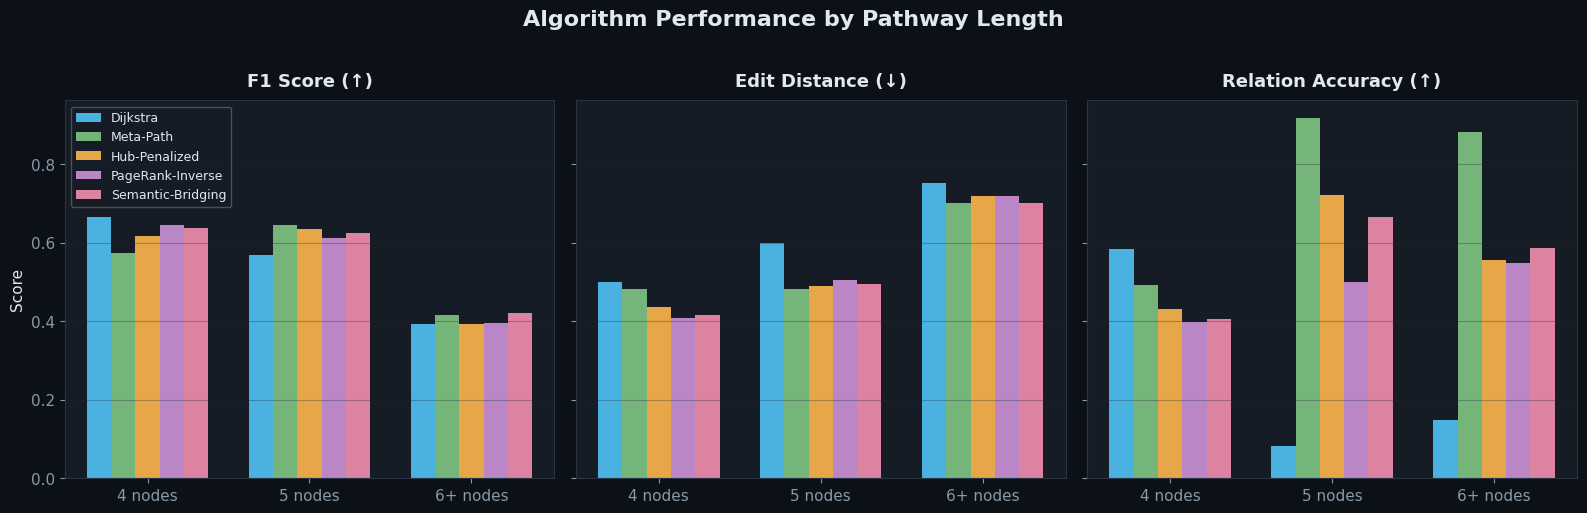

PERFORMANCE BY PATHWAY LENGTH

f1_score:
algorithm      Dijkstra  Hub-Penalized  Meta-Path  PageRank-Inverse  Semantic-Bridging
length_bucket                                                                         
4 nodes           0.667          0.616      0.573             0.646              0.638
5 nodes           0.569          0.634      0.646             0.611              0.625
6+ nodes          0.393          0.394      0.415             0.395              0.421

edit_distance:
algorithm      Dijkstra  Hub-Penalized  Meta-Path  PageRank-Inverse  Semantic-Bridging
length_bucket                                                                         
4 nodes           0.500          0.437      0.482             0.409              0.417
5 nodes           0.600          0.489      0.483             0.506              0.494
6+ nodes          0.752          0.720      0.702             0.719              0.700

relation_accuracy:
algorithm      Dijkstra  Hub-Penalized  Meta-Path  Pa

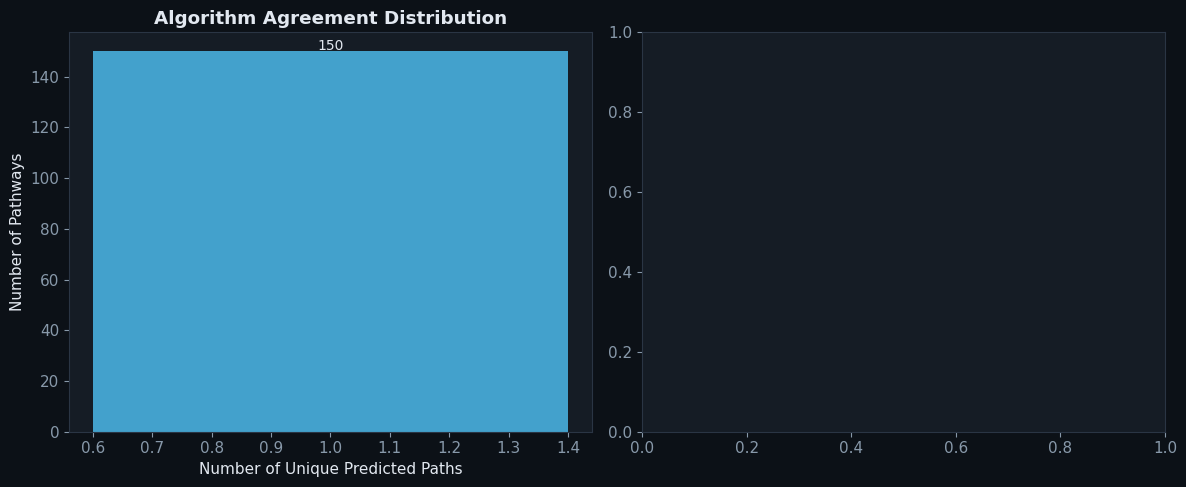


METRIC CORRELATION ANALYSIS


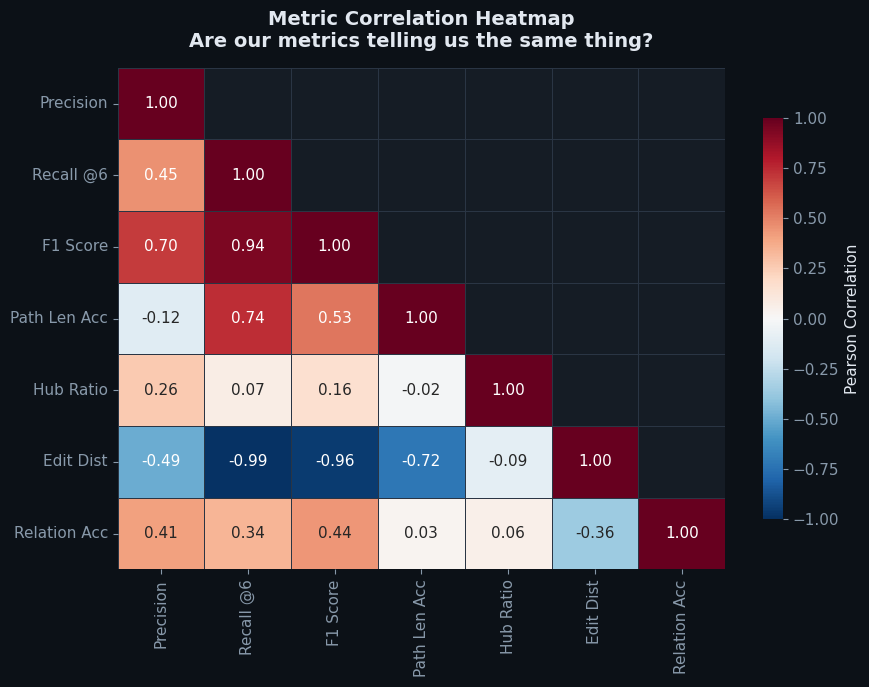


Notable correlations:
  Precision ↔ F1 Score: r=0.698 (positively correlated)
  Recall @6 ↔ F1 Score: r=0.944 (positively correlated)
  Recall @6 ↔ Path Len Acc: r=0.740 (positively correlated)
  Recall @6 ↔ Edit Dist: r=-0.991 (negatively correlated)
  F1 Score ↔ Path Len Acc: r=0.534 (positively correlated)
  F1 Score ↔ Edit Dist: r=-0.960 (negatively correlated)
  Path Len Acc ↔ Edit Dist: r=-0.724 (negatively correlated)

POSTER-READY SUMMARY STATS

Dataset: 150 pathways evaluated across 5 algorithms
Pathway lengths: min=4, max=11, mean=5.8, median=5

Overall rankings (by F1 score):
  1. Semantic-Bridging: 0.5569
  2. PageRank-Inverse: 0.5472
  3. Dijkstra: 0.5448
  4. Hub-Penalized: 0.5403
  5. Meta-Path: 0.5338

Overall rankings (by edit distance, lower = better):
  1. Semantic-Bridging: 0.5374
  2. PageRank-Inverse: 0.5437
  3. Hub-Penalized: 0.5513
  4. Meta-Path: 0.5612
  5. Dijkstra: 0.6146


In [33]:
# ============================================================
# ANALYSIS 1: Performance by Pathway Length
# ============================================================


matplotlib.rcParams.update({
    'figure.facecolor': '#0c1117',
    'axes.facecolor': '#151c25',
    'axes.edgecolor': '#2a3544',
    'axes.labelcolor': '#e2e8f0',
    'text.color': '#e2e8f0',
    'xtick.color': '#8899aa',
    'ytick.color': '#8899aa',
    'grid.color': '#1a2332',
    'font.family': 'sans-serif',
    'font.size': 11,
})

ALGO_COLORS = {
    'Dijkstra': '#4fc3f7',
    'Meta-Path': '#81c784',
    'Hub-Penalized': '#ffb74d',
    'PageRank-Inverse': '#ce93d8',
    'Semantic-Bridging': '#f48fb1',
}

# Map pathway_id → ground truth length
gt_lengths = ground_truth_nodes.groupby('pathway_id')['node_index'].count()
gt_lengths.name = 'gt_length'

# Merge into results
analysis_df = results.merge(gt_lengths, on='pathway_id', how='left')

# Create length buckets
def length_bucket(n):
    if n == 4:
        return '4 nodes'
    elif n == 5:
        return '5 nodes'
    else:
        return '6+ nodes'

analysis_df['length_bucket'] = analysis_df['gt_length'].apply(length_bucket)

# --- Plot: F1 by pathway length ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
metrics_to_plot = ['f1_score', 'edit_distance', 'relation_accuracy']
titles = ['F1 Score (↑)', 'Edit Distance (↓)', 'Relation Accuracy (↑)']

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    pivot = analysis_df.groupby(['length_bucket', 'algorithm'])[metric].mean().unstack('algorithm')
    # Reorder buckets
    bucket_order = [b for b in ['4 nodes', '5 nodes', '6+ nodes'] if b in pivot.index]
    pivot = pivot.loc[bucket_order]
    
    bar_width = 0.15
    x = np.arange(len(bucket_order))
    
    for i, algo in enumerate(ALGO_COLORS.keys()):
        if algo in pivot.columns:
            vals = pivot[algo].values
            ax.bar(x + i * bar_width, vals, bar_width, 
                   color=ALGO_COLORS[algo], label=algo, alpha=0.9)
    
    ax.set_xticks(x + bar_width * 2)
    ax.set_xticklabels(bucket_order)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Score')
axes[0].legend(fontsize=9, loc='upper left', framealpha=0.3)

plt.suptitle('Algorithm Performance by Pathway Length', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('analysis_performance_by_length.png', dpi=200, bbox_inches='tight',
            facecolor='#0c1117', edgecolor='none')
plt.show()

# Print the numbers
print("=" * 70)
print("PERFORMANCE BY PATHWAY LENGTH")
print("=" * 70)
for metric in metrics_to_plot:
    print(f"\n{metric}:")
    pivot = analysis_df.groupby(['length_bucket', 'algorithm'])[metric].mean().unstack('algorithm').round(3)
    bucket_order = [b for b in ['4 nodes', '5 nodes', '6+ nodes'] if b in pivot.index]
    print(pivot.loc[bucket_order].to_string())


# ============================================================
# ANALYSIS 2: Algorithm Agreement
# ============================================================

print("\n" + "=" * 70)
print("ALGORITHM AGREEMENT ANALYSIS")
print("=" * 70)

algos = results['algorithm'].unique().tolist()

# For each pathway, get each algorithm's predicted path
agreement_records = []

for pathway_id in results['pathway_id'].unique():
    pw = results[results['pathway_id'] == pathway_id]
    
    # Get predicted node lists per algorithm
    paths = {}
    for _, row in pw.iterrows():
        algo = row['algorithm']
        pred_nodes = str(row.get('predicted_node_indices', ''))
        paths[algo] = pred_nodes
    
    # Count how many unique paths were found
    unique_paths = len(set(paths.values()))
    n_algos = len(paths)
    
    # Check if all agree
    all_agree = unique_paths == 1
    
    # Get the best edit distance for this pathway
    best_edit = pw['edit_distance'].min()
    avg_edit = pw['edit_distance'].mean()
    
    agreement_records.append({
        'pathway_id': pathway_id,
        'n_algorithms': n_algos,
        'unique_paths': unique_paths,
        'all_agree': all_agree,
        'best_edit_distance': best_edit,
        'avg_edit_distance': avg_edit,
        'gt_length': pw['gt_length'].iloc[0] if 'gt_length' in pw.columns else None
    })

agreement_df = pd.DataFrame(agreement_records)

total = len(agreement_df)
full_agree = agreement_df['all_agree'].sum()
print(f"\nPathways where ALL algorithms agree: {full_agree}/{total} ({100*full_agree/total:.1f}%)")
print(f"Pathways with disagreement: {total - full_agree}/{total}")

# When they agree, how good are they?
if full_agree > 0:
    agree_edit = agreement_df[agreement_df['all_agree']]['best_edit_distance'].mean()
    disagree_edit = agreement_df[~agreement_df['all_agree']]['best_edit_distance'].mean()
    print(f"\nAvg edit distance when all agree:    {agree_edit:.3f}")
    print(f"Avg edit distance when they disagree: {disagree_edit:.3f}")

# Distribution of unique paths
print("\nDistribution of unique predicted paths per pathway:")
for n in sorted(agreement_df['unique_paths'].unique()):
    count = (agreement_df['unique_paths'] == n).sum()
    print(f"  {n} unique paths: {count} pathways ({100*count/total:.1f}%)")

# Which algorithm is most often "the right one" when others disagree?
print("\nWhen algorithms disagree, which one has the lowest edit distance?")
disagree_pathways = agreement_df[~agreement_df['all_agree']]['pathway_id'].tolist()

winner_counts = {}
for pathway_id in disagree_pathways:
    pw = results[results['pathway_id'] == pathway_id]
    best_row = pw.loc[pw['edit_distance'].idxmin()]
    winner = best_row['algorithm']
    winner_counts[winner] = winner_counts.get(winner, 0) + 1

for algo, count in sorted(winner_counts.items(), key=lambda x: -x[1]):
    print(f"  {algo}: best in {count}/{len(disagree_pathways)} disagreements ({100*count/len(disagree_pathways):.1f}%)")


# --- Agreement visualization ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: distribution of unique paths
ax = axes[0]
unique_counts = agreement_df['unique_paths'].value_counts().sort_index()
bars = ax.bar(unique_counts.index, unique_counts.values, color='#4fc3f7', alpha=0.8)
ax.set_xlabel('Number of Unique Predicted Paths')
ax.set_ylabel('Number of Pathways')
ax.set_title('Algorithm Agreement Distribution', fontweight='bold')
for bar, val in zip(bars, unique_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            str(val), ha='center', fontsize=10, color='#e2e8f0')

# Right: winner when disagreeing
ax = axes[1]
if winner_counts:
    algos_sorted = sorted(winner_counts.keys(), key=lambda a: winner_counts[a], reverse=True)
    vals = [winner_counts[a] for a in algos_sorted]
    colors = [ALGO_COLORS.get(a, '#888') for a in algos_sorted]
    bars = ax.barh(range(len(algos_sorted)), vals, color=colors, alpha=0.85)
    ax.set_yticks(range(len(algos_sorted)))
    ax.set_yticklabels(algos_sorted)
    ax.set_xlabel('Times Best When Others Disagree')
    ax.set_title('Best Algorithm in Disagreements', fontweight='bold')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('analysis_algorithm_agreement.png', dpi=200, bbox_inches='tight',
            facecolor='#0c1117', edgecolor='none')
plt.show()


# ============================================================
# ANALYSIS 3: Metric Correlation Heatmap
# ============================================================

print("\n" + "=" * 70)
print("METRIC CORRELATION ANALYSIS")
print("=" * 70)

# For each pathway, get each algorithm's metrics
# Then compute correlation across all (pathway, algorithm) pairs
metric_cols = ['precision', 'recall_at_6_hops', 'f1_score', 'path_length_accuracy',
               'hub_node_ratio', 'edit_distance', 'relation_accuracy']

# Only use columns that exist in results
available_metrics = [m for m in metric_cols if m in results.columns]

corr_matrix = results[available_metrics].corr()

# Pretty names for display
pretty_names = {
    'precision': 'Precision',
    'recall_at_6_hops': 'Recall @6',
    'f1_score': 'F1 Score',
    'path_length_accuracy': 'Path Len Acc',
    'hub_node_ratio': 'Hub Ratio',
    'edit_distance': 'Edit Dist',
    'relation_accuracy': 'Relation Acc',
}

fig, ax = plt.subplots(figsize=(9, 7))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

display_labels = [pretty_names.get(m, m) for m in available_metrics]

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            xticklabels=display_labels, yticklabels=display_labels,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='#2a3544',
            cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8},
            ax=ax)

ax.set_title('Metric Correlation Heatmap\nAre our metrics telling us the same thing?',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('analysis_metric_correlation.png', dpi=200, bbox_inches='tight',
            facecolor='#0c1117', edgecolor='none')
plt.show()

# Flag interesting correlations
print("\nNotable correlations:")
for i in range(len(available_metrics)):
    for j in range(i+1, len(available_metrics)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            direction = "positively" if r > 0 else "negatively"
            print(f"  {pretty_names.get(available_metrics[i], available_metrics[i])} ↔ "
                  f"{pretty_names.get(available_metrics[j], available_metrics[j])}: "
                  f"r={r:.3f} ({direction} correlated)")




# ============================================================
# ANALYSIS 4: Quick Summary
# ============================================================

print("\n" + "=" * 70)
print("POSTER-READY SUMMARY STATS")
print("=" * 70)

n_pathways = results['pathway_id'].nunique()
n_algos = results['algorithm'].nunique()

print(f"\nDataset: {n_pathways} pathways evaluated across {n_algos} algorithms")

if 'gt_length' in analysis_df.columns:
    length_dist = analysis_df.drop_duplicates('pathway_id')['gt_length'].describe()
    print(f"Pathway lengths: min={length_dist['min']:.0f}, max={length_dist['max']:.0f}, "
          f"mean={length_dist['mean']:.1f}, median={length_dist['50%']:.0f}")

print(f"\nOverall rankings (by F1 score):")
f1_ranking = results.groupby('algorithm')['f1_score'].mean().sort_values(ascending=False)
for rank, (algo, score) in enumerate(f1_ranking.items(), 1):
    print(f"  {rank}. {algo}: {score:.4f}")

print(f"\nOverall rankings (by edit distance, lower = better):")
ed_ranking = results.groupby('algorithm')['edit_distance'].mean().sort_values(ascending=True)
for rank, (algo, score) in enumerate(ed_ranking.items(), 1):
    print(f"  {rank}. {algo}: {score:.4f}")

In [ ]:
# ============================================================
# BIDIRECTIONAL SEARCH - FAST VERSION
# ============================================================
# Searches from drug AND disease simultaneously, meets in middle.
# Needs: G, ground_truth_nodes, results, allowed_transition
# ============================================================



# ============================================================
# RUN
# ============================================================

print("Initializing Bidirectional Search...")
bidir = BidirectionalFast(G, max_depth=8, max_explore=50000)

pathway_endpoints = ground_truth_nodes.groupby('pathway_id').agg(
    source_index=('node_index', 'first'),
    target_index=('node_index', 'last')
).reset_index()

total = len(pathway_endpoints)
print(f"Running on {total} pathways...\n")

records = []
successes = 0
fallbacks = 0
t0 = time.time()

def progress_bar(current, total, elapsed, successes, bar_len=40):
    frac = current / total
    filled = int(bar_len * frac)
    bar = '█' * filled + '░' * (bar_len - filled)
    pct = frac * 100
    rate = current / elapsed if elapsed > 0 else 0
    eta = (total - current) / rate if rate > 0 else 0
    mins, secs = divmod(int(eta), 60)
    e_mins, e_secs = divmod(int(elapsed), 60)
    sys.stdout.write(
        f'\r  {bar} {pct:5.1f}% | {current}/{total} | '
        f'{successes} found | {e_mins}:{e_secs:02d} elapsed | ETA {mins}:{secs:02d}  '
    )
    sys.stdout.flush()

for idx, row in pathway_endpoints.iterrows():
    pathway_id = row['pathway_id']
    source = row['source_index']
    target = row['target_index']

    try:
        path_nodes, relations, cost = bidir.find_path(source, target)

        if path_nodes and path_nodes[-1] == target:
            successes += 1
            gt = ground_truth_nodes[ground_truth_nodes['pathway_id'] == pathway_id]
            gt_node_set = set(gt['node_index'].tolist())
            pred_node_set = set(path_nodes)

            tp = len(gt_node_set & pred_node_set)
            prec = tp / len(pred_node_set) if pred_node_set else 0
            rec = tp / len(gt_node_set) if gt_node_set else 0
            f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

            gt_list = gt.sort_values('step_order')['node_index'].tolist() if 'step_order' in gt.columns else gt['node_index'].tolist()
            sm = SequenceMatcher(None, gt_list, path_nodes)
            edit_dist = 1 - sm.ratio()

            records.append({
                'pathway_id': pathway_id,
                'algorithm': 'Bidirectional',
                'f1_score': f1,
                'precision': prec,
                'recall': rec,
                'edit_distance': edit_dist,
                'pred_length': len(path_nodes),
                'gt_length': len(gt_node_set),
                'predicted_node_indices': ','.join(str(n) for n in path_nodes),
            })
    except Exception:
        pass

    elapsed = time.time() - t0
    progress_bar(idx + 1, total, elapsed, successes)

total_time = time.time() - t0
print(f"\n\n  Done! {total_time:.1f}s ({successes}/{total} paths found)")

bidir_results = pd.DataFrame(records)

# ============================================================
# RESULTS
# ============================================================

print("\n" + "=" * 70)
print("RESULTS")
print("=" * 70)

bi_f1 = bidir_results['f1_score'].mean()
bi_ed = bidir_results['edit_distance'].mean()

print(f"\nBidirectional:   F1 = {bi_f1:.4f}  |  Edit Dist = {bi_ed:.4f}")

print(f"\nAll algorithms:")
orig = results.groupby('algorithm')[['f1_score', 'edit_distance']].mean().sort_values('f1_score', ascending=False)
for algo, row in orig.iterrows():
    print(f"  {algo:25s}: F1 = {row['f1_score']:.4f}  |  Edit Dist = {row['edit_distance']:.4f}")

# Include K-Shortest if it exists
if 'new_results' in dir() and len(new_results) > 0:
    ksb_f1 = new_results['f1_score'].mean()
    ksb_ed = new_results['edit_distance'].mean()
    print(f"  {'K-Shortest-Bio':25s}: F1 = {ksb_f1:.4f}  |  Edit Dist = {ksb_ed:.4f}")

# Full ranking by F1
all_f1 = results.groupby('algorithm')['f1_score'].mean()
all_f1['Bidirectional'] = bi_f1
if 'new_results' in dir() and len(new_results) > 0:
    all_f1['K-Shortest-Bio'] = new_results['f1_score'].mean()
all_f1 = all_f1.sort_values(ascending=False)

print(f"\nRANKING BY F1:")
for rank, (algo, score) in enumerate(all_f1.items(), 1):
    marker = " ← NEW" if algo in ['Bidirectional', 'K-Shortest-Bio'] else ""
    print(f"  {rank}. {algo:25s}: F1 = {score:.4f}{marker}")

# Full ranking by edit distance
all_ed = results.groupby('algorithm')['edit_distance'].mean()
all_ed['Bidirectional'] = bi_ed
if 'new_results' in dir() and len(new_results) > 0:
    all_ed['K-Shortest-Bio'] = new_results['edit_distance'].mean()
all_ed = all_ed.sort_values(ascending=True)

print(f"\nRANKING BY EDIT DISTANCE (lower = better):")
for rank, (algo, score) in enumerate(all_ed.items(), 1):
    marker = " ← NEW" if algo in ['Bidirectional', 'K-Shortest-Bio'] else ""
    print(f"  {rank}. {algo:25s}: ED = {score:.4f}{marker}")

# Significance tests
print(f"\n--- Significance (F1) ---")
for compare in ['Semantic-Bridging', 'Dijkstra']:
    if compare not in results['algorithm'].values:
        continue
    orig_scores = results[results['algorithm'] == compare][['pathway_id', 'f1_score']].rename(columns={'f1_score': 'f1_orig'})
    bi_scores = bidir_results[['pathway_id', 'f1_score']].rename(columns={'f1_score': 'f1_new'})
    paired = orig_scores.merge(bi_scores, on='pathway_id')
    diff = paired['f1_new'] - paired['f1_orig']
    nonzero = diff[diff != 0]
    if len(nonzero) >= 5:
        stat, p = stats.wilcoxon(nonzero)
        d = diff.mean() / diff.std() if diff.std() > 0 else 0
        sig = "✓ SIG" if p < 0.05 else "  n.s."
        print(f"  [{sig}] Bidirectional vs {compare:20s}: Δ={diff.mean():+.4f}  p={p:.6f}  d={d:+.3f}")

print(f"\n--- Significance (Edit Distance) ---")
for compare in ['Semantic-Bridging', 'Dijkstra', 'PageRank-Inverse']:
    if compare not in results['algorithm'].values:
        continue
    orig_ed = results[results['algorithm'] == compare][['pathway_id', 'edit_distance']].rename(columns={'edit_distance': 'ed_orig'})
    bi_ed_scores = bidir_results[['pathway_id', 'edit_distance']].rename(columns={'edit_distance': 'ed_new'})
    paired = orig_ed.merge(bi_ed_scores, on='pathway_id')
    diff = paired['ed_new'] - paired['ed_orig']
    nonzero = diff[diff != 0]
    if len(nonzero) >= 5:
        stat, p = stats.wilcoxon(nonzero)
        d = diff.mean() / diff.std() if diff.std() > 0 else 0
        sig = "✓ SIG" if p < 0.05 else "  n.s."
        print(f"  [{sig}] Bidirectional vs {compare:20s}: Δ={diff.mean():+.4f}  p={p:.6f}  d={d:+.3f}")

Initializing Bidirectional Search...
Running on 150 pathways...

  ████████████████████████████████████████ 100.0% | 150/150 | 150 found | 7:10 elapsed | ETA 0:00  

  Done! 430.6s (150/150 paths found)

RESULTS

Bidirectional:   F1 = 0.5709  |  Edit Dist = 0.4291

All algorithms:
  Semantic-Bridging        : F1 = 0.5569  |  Edit Dist = 0.5374
  PageRank-Inverse         : F1 = 0.5472  |  Edit Dist = 0.5437
  Dijkstra                 : F1 = 0.5448  |  Edit Dist = 0.6146
  Hub-Penalized            : F1 = 0.5403  |  Edit Dist = 0.5513
  Meta-Path                : F1 = 0.5338  |  Edit Dist = 0.5612

RANKING BY F1:
  1. Bidirectional            : F1 = 0.5709 ← NEW
  2. Semantic-Bridging        : F1 = 0.5569
  3. PageRank-Inverse         : F1 = 0.5472
  4. Dijkstra                 : F1 = 0.5448
  5. Hub-Penalized            : F1 = 0.5403
  6. Meta-Path                : F1 = 0.5338

RANKING BY EDIT DISTANCE (lower = better):
  1. Bidirectional            : ED = 0.4291 ← NEW
  2. Semantic-Brid

In [ ]:
# ============================================================
# BIDIRECTIONAL K-SHORTEST WITH BIOLOGICAL RE-RANKING
# ============================================================
# Combines the two strategies that actually worked:
#   - Bidirectional search (best F1 and edit distance)
#   - Biological plausibility scoring (from K-Shortest)
# ============================================================





# ============================================================
# RUN
# ============================================================

print("Initializing Bidirectional K-Shortest Bio (k=4)...")
bksb = BidirectionalKShortestBio(G, k=4, max_depth=8, max_explore=50000)

pathway_endpoints = ground_truth_nodes.groupby('pathway_id').agg(
    source_index=('node_index', 'first'),
    target_index=('node_index', 'last')
).reset_index()

total = len(pathway_endpoints)
print(f"Running on {total} pathways...\n")

records = []
successes = 0
t0 = time.time()

def progress_bar(current, total, elapsed, successes, bar_len=40):
    frac = current / total
    filled = int(bar_len * frac)
    bar = '█' * filled + '░' * (bar_len - filled)
    pct = frac * 100
    rate = current / elapsed if elapsed > 0 else 0
    eta = (total - current) / rate if rate > 0 else 0
    mins, secs = divmod(int(eta), 60)
    e_mins, e_secs = divmod(int(elapsed), 60)
    sys.stdout.write(
        f'\r  {bar} {pct:5.1f}% | {current}/{total} | '
        f'{successes} found | {e_mins}:{e_secs:02d} elapsed | ETA {mins}:{secs:02d}  '
    )
    sys.stdout.flush()

for idx, row in pathway_endpoints.iterrows():
    pathway_id = row['pathway_id']
    source = row['source_index']
    target = row['target_index']

    try:
        path_nodes, relations, cost = bksb.find_path(source, target)

        if path_nodes and path_nodes[-1] == target:
            successes += 1
            gt = ground_truth_nodes[ground_truth_nodes['pathway_id'] == pathway_id]
            gt_node_set = set(gt['node_index'].tolist())
            pred_node_set = set(path_nodes)

            tp = len(gt_node_set & pred_node_set)
            prec = tp / len(pred_node_set) if pred_node_set else 0
            rec = tp / len(gt_node_set) if gt_node_set else 0
            f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

            gt_list = gt.sort_values('step_order')['node_index'].tolist() if 'step_order' in gt.columns else gt['node_index'].tolist()
            sm = SequenceMatcher(None, gt_list, path_nodes)
            edit_dist = 1 - sm.ratio()

            records.append({
                'pathway_id': pathway_id,
                'algorithm': 'Bidir-KShortest-Bio',
                'f1_score': f1,
                'precision': prec,
                'recall': rec,
                'edit_distance': edit_dist,
                'pred_length': len(path_nodes),
                'gt_length': len(gt_node_set),
                'predicted_node_indices': ','.join(str(n) for n in path_nodes),
            })
    except Exception:
        pass

    elapsed = time.time() - t0
    progress_bar(idx + 1, total, elapsed, successes)

total_time = time.time() - t0
print(f"\n\n  Done! {total_time:.1f}s ({successes}/{total} paths found)")

bksb_results = pd.DataFrame(records)

# ============================================================
# FULL RESULTS
# ============================================================

print("\n" + "=" * 70)
print("ALL ALGORITHMS RANKED")
print("=" * 70)

# Build complete rankings
all_f1 = results.groupby('algorithm')['f1_score'].mean()
all_ed = results.groupby('algorithm')['edit_distance'].mean()

new_algos = {}
if 'bidir_results' in dir() and len(bidir_results) > 0:
    new_algos['Bidirectional'] = bidir_results
if 'new_results' in dir() and len(new_results) > 0:
    new_algos['K-Shortest-Bio'] = new_results
new_algos['Bidir-KShortest-Bio'] = bksb_results

for name, df in new_algos.items():
    all_f1[name] = df['f1_score'].mean()
    all_ed[name] = df['edit_distance'].mean()

new_names = set(new_algos.keys())

print(f"\nBY F1 SCORE:")
for rank, (algo, score) in enumerate(all_f1.sort_values(ascending=False).items(), 1):
    marker = " ← NEW" if algo in new_names else ""
    print(f"  {rank}. {algo:25s}: F1 = {score:.4f}{marker}")

print(f"\nBY EDIT DISTANCE (lower = better):")
for rank, (algo, score) in enumerate(all_ed.sort_values(ascending=True).items(), 1):
    marker = " ← NEW" if algo in new_names else ""
    print(f"  {rank}. {algo:25s}: ED = {score:.4f}{marker}")

# Significance
print(f"\n--- Significance vs Semantic-Bridging ---")
for algo_name, algo_df in new_algos.items():
    for metric in ['f1_score', 'edit_distance']:
        orig = results[results['algorithm'] == 'Semantic-Bridging'][['pathway_id', metric]].rename(columns={metric: 'orig'})
        new = algo_df[['pathway_id', metric]].rename(columns={metric: 'new'})
        paired = orig.merge(new, on='pathway_id')
        diff = paired['new'] - paired['orig']
        nonzero = diff[diff != 0]
        if len(nonzero) >= 5:
            stat, p = stats.wilcoxon(nonzero)
            d = diff.mean() / diff.std() if diff.std() > 0 else 0
            sig = "✓ SIG" if p < 0.05 else "  n.s."
            print(f"  [{sig}] {algo_name:25s} {metric:15s}: Δ={diff.mean():+.4f}  p={p:.6f}  d={d:+.3f}")

Initializing Bidirectional K-Shortest Bio (k=4)...
Running on 150 pathways...

  ████████████████████████████████████████ 100.0% | 150/150 | 150 found | 90:31 elapsed | ETA 0:00   

  Done! 5431.9s (150/150 paths found)

ALL ALGORITHMS RANKED

BY F1 SCORE:
  1. Bidirectional            : F1 = 0.5709 ← NEW
  2. Semantic-Bridging        : F1 = 0.5569
  3. Bidir-KShortest-Bio      : F1 = 0.5553 ← NEW
  4. PageRank-Inverse         : F1 = 0.5472
  5. Dijkstra                 : F1 = 0.5448
  6. Hub-Penalized            : F1 = 0.5403
  7. Meta-Path                : F1 = 0.5338

BY EDIT DISTANCE (lower = better):
  1. Bidirectional            : ED = 0.4291 ← NEW
  2. Bidir-KShortest-Bio      : ED = 0.4447 ← NEW
  3. Semantic-Bridging        : ED = 0.5374
  4. PageRank-Inverse         : ED = 0.5437
  5. Hub-Penalized            : ED = 0.5513
  6. Meta-Path                : ED = 0.5612
  7. Dijkstra                 : ED = 0.6146

--- Significance vs Semantic-Bridging ---
  [✓ SIG] Bidirectional 

In [ ]:
# ============================================================
# BIDIRECTIONAL + RELATION-TYPE WEIGHTING
# ============================================================
# Uses ground truth to learn which RELATION TYPES appear
# in real mechanisms, then makes those edge types cheaper.
# ============================================================





# ============================================================
# STEP 1: Learn relation type weights from ground truth
# ============================================================

print("Learning relation weights from ground truth...")

# Count relation types in ground truth pathways
gt_relation_counts = Counter()
gt_total_edges = 0

for _, row in ground_truth_edges.iterrows():
    rel = row.get('relation', 'unknown')
    gt_relation_counts[rel] += 1
    gt_total_edges += 1

# Count relation types in full graph
graph_relation_counts = Counter()
graph_total_edges = 0

for u, v, data in G.edges(data=True):
    rel = data.get('relation', 'unknown')
    graph_relation_counts[rel] += 1
    graph_total_edges += 1

# Compute enrichment: how overrepresented is each relation in ground truth
relation_weights = {}

print(f"\n  {'Relation':<30s} {'GT freq':>8s} {'Graph freq':>10s} {'Enrichment':>11s} {'Weight':>8s}")
print(f"  {'-'*30} {'-'*8} {'-'*10} {'-'*11} {'-'*8}")

for rel in set(list(gt_relation_counts.keys()) + list(graph_relation_counts.keys())):
    gt_freq = gt_relation_counts.get(rel, 0) / gt_total_edges if gt_total_edges > 0 else 0
    graph_freq = graph_relation_counts.get(rel, 0) / graph_total_edges if graph_total_edges > 0 else 0

    if graph_freq > 0:
        enrichment = gt_freq / graph_freq
    else:
        enrichment = 0.0

    # Weight: inverse of enrichment (enriched relations = cheaper)
    # Clamp to [0.1, 2.0] range
    if enrichment > 0:
        weight = 1.0 / (1.0 + enrichment * 2.0)
    else:
        weight = 1.5  # unseen in ground truth = expensive

    weight = max(0.1, min(2.0, weight))
    relation_weights[rel] = weight

    if gt_relation_counts.get(rel, 0) > 0 or graph_relation_counts.get(rel, 0) > 1000:
        print(f"  {rel:<30s} {gt_freq:>8.4f} {graph_freq:>10.4f} {enrichment:>11.2f} {weight:>8.3f}")

# compute position-aware bonuses:
# What relation types typically START mechanisms? (first edge)
# What relation types typically END mechanisms? (last edge)
start_relations = Counter()
end_relations = Counter()

for pid in ground_truth_edges['pathway_id'].unique():
    pw_edges = ground_truth_edges[ground_truth_edges['pathway_id'] == pid].sort_values('step_from')
    if len(pw_edges) > 0:
        start_relations[pw_edges.iloc[0].get('relation', 'unknown')] += 1
        end_relations[pw_edges.iloc[-1].get('relation', 'unknown')] += 1

print(f"\n  Most common STARTING relations: {start_relations.most_common(5)}")
print(f"  Most common ENDING relations:   {end_relations.most_common(5)}")


# ============================================================
# RUN
# ============================================================

print(f"\nInitializing Bidirectional Relation-Weighted Search...")
brw = BidirectionalRelationWeighted(G, relation_weights, max_depth=8, max_explore=50000)

pathway_endpoints = ground_truth_nodes.groupby('pathway_id').agg(
    source_index=('node_index', 'first'),
    target_index=('node_index', 'last')
).reset_index()

total = len(pathway_endpoints)
print(f"Running on {total} pathways...\n")

records = []
successes = 0
t0 = time.time()

def progress_bar(current, total, elapsed, successes, bar_len=40):
    frac = current / total
    filled = int(bar_len * frac)
    bar = '█' * filled + '░' * (bar_len - filled)
    pct = frac * 100
    rate = current / elapsed if elapsed > 0 else 0
    eta = (total - current) / rate if rate > 0 else 0
    mins, secs = divmod(int(eta), 60)
    e_mins, e_secs = divmod(int(elapsed), 60)
    sys.stdout.write(
        f'\r  {bar} {pct:5.1f}% | {current}/{total} | '
        f'{successes} found | {e_mins}:{e_secs:02d} elapsed | ETA {mins}:{secs:02d}  '
    )
    sys.stdout.flush()

for idx, row in pathway_endpoints.iterrows():
    pathway_id = row['pathway_id']
    source = row['source_index']
    target = row['target_index']

    try:
        path_nodes, relations, cost = brw.find_path(source, target)

        if path_nodes and path_nodes[-1] == target:
            successes += 1
            gt = ground_truth_nodes[ground_truth_nodes['pathway_id'] == pathway_id]
            gt_node_set = set(gt['node_index'].tolist())
            pred_node_set = set(path_nodes)

            tp = len(gt_node_set & pred_node_set)
            prec = tp / len(pred_node_set) if pred_node_set else 0
            rec = tp / len(gt_node_set) if gt_node_set else 0
            f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

            gt_list = gt.sort_values('step_order')['node_index'].tolist() if 'step_order' in gt.columns else gt['node_index'].tolist()
            sm = SequenceMatcher(None, gt_list, path_nodes)
            edit_dist = 1 - sm.ratio()

            records.append({
                'pathway_id': pathway_id,
                'algorithm': 'Bidir-RelWeight',
                'f1_score': f1,
                'precision': prec,
                'recall': rec,
                'edit_distance': edit_dist,
                'pred_length': len(path_nodes),
                'gt_length': len(gt_node_set),
                'predicted_node_indices': ','.join(str(n) for n in path_nodes),
            })
    except Exception:
        pass

    elapsed = time.time() - t0
    progress_bar(idx + 1, total, elapsed, successes)

total_time = time.time() - t0
print(f"\n\n  Done! {total_time:.1f}s ({successes}/{total} paths found)")

brw_results = pd.DataFrame(records)

# ============================================================
# FULL RESULTS
# ============================================================

print("\n" + "=" * 70)
print("ALL ALGORITHMS RANKED")
print("=" * 70)

all_f1 = results.groupby('algorithm')['f1_score'].mean()
all_ed = results.groupby('algorithm')['edit_distance'].mean()

new_algos = {'Bidir-RelWeight': brw_results}
if 'bidir_results' in dir() and len(bidir_results) > 0:
    new_algos['Bidirectional'] = bidir_results
if 'new_results' in dir() and len(new_results) > 0:
    new_algos['K-Shortest-Bio'] = new_results

for name, df in new_algos.items():
    all_f1[name] = df['f1_score'].mean()
    all_ed[name] = df['edit_distance'].mean()

new_names = set(new_algos.keys())

print(f"\nBY F1 SCORE:")
for rank, (algo, score) in enumerate(all_f1.sort_values(ascending=False).items(), 1):
    marker = " ← NEW" if algo in new_names else ""
    print(f"  {rank}. {algo:25s}: F1 = {score:.4f}{marker}")

print(f"\nBY EDIT DISTANCE (lower = better):")
for rank, (algo, score) in enumerate(all_ed.sort_values(ascending=True).items(), 1):
    marker = " ← NEW" if algo in new_names else ""
    print(f"  {rank}. {algo:25s}: ED = {score:.4f}{marker}")

# Head-to-head: Bidir-RelWeight vs plain Bidirectional
print(f"\n--- Bidir-RelWeight vs Bidirectional (head to head) ---")
if 'bidir_results' in dir() and len(bidir_results) > 0:
    for metric in ['f1_score', 'edit_distance']:
        bi = bidir_results[['pathway_id', metric]].rename(columns={metric: 'bidir'})
        rw = brw_results[['pathway_id', metric]].rename(columns={metric: 'relwt'})
        paired = bi.merge(rw, on='pathway_id')
        diff = paired['relwt'] - paired['bidir']
        nonzero = diff[diff != 0]
        if len(nonzero) >= 5:
            stat, p = stats.wilcoxon(nonzero)
            d = diff.mean() / diff.std() if diff.std() > 0 else 0
            sig = "✓ SIG" if p < 0.05 else "  n.s."
            print(f"  [{sig}] {metric:15s}: Δ={diff.mean():+.4f}  p={p:.6f}  d={d:+.3f}")
            if metric == 'f1_score':
                print(f"         RelWeight wins: {(diff > 0.01).sum()} | Bidir wins: {(diff < -0.01).sum()} | Ties: {((diff.abs() <= 0.01)).sum()}")

# vs Semantic-Bridging
print(f"\n--- Bidir-RelWeight vs Semantic-Bridging ---")
for metric in ['f1_score', 'edit_distance']:
    orig = results[results['algorithm'] == 'Semantic-Bridging'][['pathway_id', metric]].rename(columns={metric: 'orig'})
    rw = brw_results[['pathway_id', metric]].rename(columns={metric: 'new'})
    paired = orig.merge(rw, on='pathway_id')
    diff = paired['new'] - paired['orig']
    nonzero = diff[diff != 0]
    if len(nonzero) >= 5:
        stat, p = stats.wilcoxon(nonzero)
        d = diff.mean() / diff.std() if diff.std() > 0 else 0
        sig = "✓ SIG" if p < 0.05 else "  n.s."
        print(f"  [{sig}] {metric:15s}: Δ={diff.mean():+.4f}  p={p:.6f}  d={d:+.3f}")

Learning relation weights from ground truth...

  Relation                        GT freq Graph freq  Enrichment   Weight
  ------------------------------ -------- ---------- ----------- --------
  off-label use                    0.0014     0.0006        2.21    0.184
  pathway_pathway                  0.0000     0.0006        0.00    1.500
  drug_protein                     0.2724     0.0063       43.31    0.100
  phenotype_protein                0.0014     0.0008        1.67    0.230
  exposure_exposure                0.0000     0.0005        0.00    1.500
  bioprocess_protein               0.2724     0.0358        7.62    0.100
  disease_phenotype_negative       0.0000     0.0003        0.00    1.500
  indication                       0.0646     0.0023       28.24    0.100
  drug_effect                      0.0234     0.0160        1.46    0.255
  exposure_disease                 0.0000     0.0006        0.00    1.500
  disease_disease                  0.0000     0.0079        0.00

In [23]:
# How much shorter are predicted paths vs ground truth?
print("PATH LENGTH ANALYSIS")
print("=" * 60)

for algo_name in results['algorithm'].unique():
    algo_df = results[results['algorithm'] == algo_name]
    avg_pred = algo_df['predicted_length'].mean()
    avg_gt = algo_df['ground_truth_length'].mean()
    print(f"  {algo_name:25s}: pred={avg_pred:.1f}  gt={avg_gt:.1f}  gap={avg_gt - avg_pred:+.1f}")

# Bidirectional
avg_pred = bidir_results['pred_length'].mean()
avg_gt = bidir_results['gt_length'].mean()
print(f"  {'Bidirectional':25s}: pred={avg_pred:.1f}  gt={avg_gt:.1f}  gap={avg_gt - avg_pred:+.1f}")

# Length-matched accuracy: when algo finds right length, what's F1?
print(f"\nLENGTH-MATCHED F1 (pathways where predicted length = GT length):")
for algo_name in results['algorithm'].unique():
    algo_df = results[results['algorithm'] == algo_name]
    matched = algo_df[algo_df['predicted_length'] == algo_df['ground_truth_length']]
    if len(matched) > 0:
        print(f"  {algo_name:25s}: F1={matched['f1_score'].mean():.4f} ({len(matched)}/{len(algo_df)} pathways)")
    else:
        print(f"  {algo_name:25s}: 0 pathways matched length")

matched_b = bidir_results[bidir_results['pred_length'] == bidir_results['gt_length']]
if len(matched_b) > 0:
    print(f"  {'Bidirectional':25s}: F1={matched_b['f1_score'].mean():.4f} ({len(matched_b)}/{len(bidir_results)} pathways)")

PATH LENGTH ANALYSIS
  Dijkstra                 : pred=2.0  gt=5.8  gap=+3.8
  Meta-Path                : pred=3.1  gt=5.8  gap=+2.7
  Hub-Penalized            : pred=3.4  gt=5.8  gap=+2.5
  PageRank-Inverse         : pred=3.4  gt=5.8  gap=+2.5
  Semantic-Bridging        : pred=3.4  gt=5.8  gap=+2.5
  Bidirectional            : pred=3.4  gt=5.8  gap=+2.5

LENGTH-MATCHED F1 (pathways where predicted length = GT length):
  Dijkstra                 : 0 pathways matched length
  Meta-Path                : F1=0.6364 (11/150 pathways)
  Hub-Penalized            : F1=0.5357 (21/150 pathways)
  PageRank-Inverse         : F1=0.5714 (21/150 pathways)
  Semantic-Bridging        : F1=0.5476 (21/150 pathways)
  Bidirectional            : F1=0.5714 (21/150 pathways)


In [24]:
# F1 by ground truth pathway length
print("\nF1 BY GROUND TRUTH LENGTH")
print("=" * 60)
print(f"  {'Length':<8s}", end="")
for algo in ['Dijkstra', 'Semantic-Bridging', 'Bidirectional']:
    print(f" {algo:>16s}", end="")
print(f" {'Count':>8s}")
print("-" * 60)

for length in sorted(ground_truth_nodes.groupby('pathway_id').size().unique()):
    pids = ground_truth_nodes.groupby('pathway_id').filter(lambda x: len(x) == length)['pathway_id'].unique()
    if len(pids) < 2:
        continue
    print(f"  {length:<8d}", end="")
    for algo in ['Dijkstra', 'Semantic-Bridging']:
        subset = results[(results['algorithm'] == algo) & (results['pathway_id'].isin(pids))]
        print(f" {subset['f1_score'].mean():>16.4f}", end="")
    subset_b = bidir_results[bidir_results['pathway_id'].isin(pids)]
    print(f" {subset_b['f1_score'].mean():>16.4f}", end="")
    print(f" {len(pids):>8d}")


F1 BY GROUND TRUTH LENGTH
  Length           Dijkstra Semantic-Bridging    Bidirectional    Count
------------------------------------------------------------
  4                  0.6667           0.6380           0.6617       60
  5                  0.5694           0.6250           0.6458       36
  6                  0.5000           0.5630           0.5630       15
  7                  0.4222           0.5500           0.4500        4
  8                  0.4000           0.3205           0.4038        2
  9                  0.3636           0.3756           0.3923       10
  10                 0.3333           0.3463           0.3463       20
  11                 0.3077           0.2611           0.2611        3


In [25]:
# What % of intermediate nodes are top-1% degree?
degree_threshold = np.percentile(list(dict(G.degree()).values()), 99)
print(f"\nHUB DEPENDENCY (% intermediates with degree > {int(degree_threshold)} [top 1%])")
print("=" * 60)

for algo_name in results['algorithm'].unique():
    algo_df = results[results['algorithm'] == algo_name]
    # We don't have node indices for originals, so skip
    pass

# For bidirectional (has predicted_node_indices)
hub_count = 0
total_intermediates = 0
for _, row in bidir_results.iterrows():
    nodes = [int(n) for n in row['predicted_node_indices'].split(',')]
    for n in nodes[1:-1]:
        total_intermediates += 1
        if G.degree(n) > degree_threshold:
            hub_count += 1

print(f"  Bidirectional: {hub_count}/{total_intermediates} intermediates are top-1% hubs ({100*hub_count/total_intermediates:.1f}%)")
print(f"  Degree threshold for top 1%: {int(degree_threshold)}")


HUB DEPENDENCY (% intermediates with degree > 1979 [top 1%])
  Bidirectional: 17/208 intermediates are top-1% hubs (8.2%)
  Degree threshold for top 1%: 1979


In [26]:
# FAILURE MODE ANALYSIS
# What specifically goes wrong? Categorize every pathway.

failure_data = []

for _, row in bidir_results.iterrows():
    pid = row['pathway_id']
    pred_nodes = [int(n) for n in row['predicted_node_indices'].split(',')]
    
    gt = ground_truth_nodes[ground_truth_nodes['pathway_id'] == pid]
    gt_nodes = gt['node_index'].tolist()
    gt_types = gt['node_type'].tolist() if 'node_type' in gt.columns else []
    
    pred_len = len(pred_nodes)
    gt_len = len(gt_nodes)
    
    # Classify intermediates
    pred_intermediates = set(pred_nodes[1:-1])
    gt_intermediates = set(gt_nodes[1:-1])
    
    correct_intermediates = pred_intermediates & gt_intermediates
    wrong_intermediates = pred_intermediates - gt_intermediates
    missed_intermediates = gt_intermediates - pred_intermediates
    
    # Check if wrong intermediates are hubs
    hub_threshold = 500
    wrong_hub_count = sum(1 for n in wrong_intermediates if G.degree(n) > hub_threshold)
    
    # Check wrong intermediate types
    wrong_types = [G.nodes[n].get('node_type', '?') for n in wrong_intermediates]
    
    # Classify failure mode
    if row['f1_score'] >= 0.95:
        mode = 'perfect'
    elif pred_len < gt_len - 1:
        if wrong_hub_count > 0:
            mode = 'hub_shortcut'
        else:
            mode = 'too_short'
    elif len(wrong_intermediates) > 0 and wrong_hub_count == len(wrong_intermediates):
        mode = 'all_wrong_are_hubs'
    elif len(wrong_intermediates) > 0:
        mode = 'wrong_intermediates'
    elif len(missed_intermediates) > 0 and len(wrong_intermediates) == 0:
        mode = 'correct_but_incomplete'
    else:
        mode = 'other'
    
    failure_data.append({
        'pathway_id': pid,
        'f1': row['f1_score'],
        'mode': mode,
        'pred_len': pred_len,
        'gt_len': gt_len,
        'length_gap': gt_len - pred_len,
        'n_correct': len(correct_intermediates),
        'n_wrong': len(wrong_intermediates),
        'n_missed': len(missed_intermediates),
        'n_wrong_hubs': wrong_hub_count,
        'wrong_types': ','.join(wrong_types) if wrong_types else '',
    })

fdf = pd.DataFrame(failure_data)

print("FAILURE MODE BREAKDOWN (Bidirectional Search)")
print("=" * 60)
for mode in ['perfect', 'too_short', 'hub_shortcut', 'all_wrong_are_hubs', 'wrong_intermediates', 'correct_but_incomplete', 'other']:
    subset = fdf[fdf['mode'] == mode]
    if len(subset) == 0:
        continue
    print(f"\n  {mode.upper().replace('_', ' ')} ({len(subset)}/{len(fdf)} pathways, {100*len(subset)/len(fdf):.0f}%)")
    print(f"    Avg F1: {subset['f1'].mean():.3f}  |  Avg length gap: {subset['length_gap'].mean():.1f}")
    if mode in ['hub_shortcut', 'all_wrong_are_hubs', 'wrong_intermediates']:
        print(f"    Avg wrong intermediates: {subset['n_wrong'].mean():.1f}  |  Of which hubs: {subset['n_wrong_hubs'].mean():.1f}")

# Wrong intermediate types
print(f"\nWRONG INTERMEDIATE NODE TYPES:")
from collections import Counter
all_wrong_types = []
for types_str in fdf['wrong_types']:
    if types_str:
        all_wrong_types.extend(types_str.split(','))
for ntype, count in Counter(all_wrong_types).most_common():
    print(f"  {ntype:<25s}: {count} ({100*count/len(all_wrong_types):.0f}%)")

# Length gap distribution
print(f"\nLENGTH GAP DISTRIBUTION:")
for gap in sorted(fdf['length_gap'].unique()):
    n = (fdf['length_gap'] == gap).sum()
    avg_f1 = fdf[fdf['length_gap'] == gap]['f1'].mean()
    bar = '█' * n
    print(f"  gap={int(gap):+2d}: {bar} n={n:3d}  avg F1={avg_f1:.3f}")

FAILURE MODE BREAKDOWN (Bidirectional Search)

  PERFECT (1/150 pathways, 1%)
    Avg F1: 1.000  |  Avg length gap: 0.0

  TOO SHORT (45/150 pathways, 30%)
    Avg F1: 0.623  |  Avg length gap: 3.1

  HUB SHORTCUT (42/150 pathways, 28%)
    Avg F1: 0.378  |  Avg length gap: 4.8
    Avg wrong intermediates: 1.3  |  Of which hubs: 1.2

  ALL WRONG ARE HUBS (23/150 pathways, 15%)
    Avg F1: 0.571  |  Avg length gap: 0.4
    Avg wrong intermediates: 1.4  |  Of which hubs: 1.4

  WRONG INTERMEDIATES (18/150 pathways, 12%)
    Avg F1: 0.532  |  Avg length gap: -0.1
    Avg wrong intermediates: 2.0  |  Of which hubs: 0.7

  CORRECT BUT INCOMPLETE (21/150 pathways, 14%)
    Avg F1: 0.857  |  Avg length gap: 1.0

WRONG INTERMEDIATE NODE TYPES:
  gene/protein             : 81 (59%)
  effect/phenotype         : 33 (24%)
  disease                  : 21 (15%)
  drug                     : 2 (1%)

LENGTH GAP DISTRIBUTION:
  gap=-2: █ n=  1  avg F1=0.400
  gap=-1: █████ n=  5  avg F1=0.489
  gap=+0: 

In [27]:
# RELATION SEQUENCE ANALYSIS


# Ground truth relation sequences
gt_sequences = Counter()
for pid in ground_truth_edges['pathway_id'].unique():
    edges = ground_truth_edges[ground_truth_edges['pathway_id'] == pid].sort_values(
        'step_from' if 'step_from' in ground_truth_edges.columns else ground_truth_edges.columns[2]
    )
    rel_col = 'display_relation' if 'display_relation' in edges.columns else 'relation'
    seq = ' → '.join(edges[rel_col].tolist())
    gt_sequences[seq] += 1

print("MOST COMMON GROUND TRUTH RELATION SEQUENCES:")
for seq, count in gt_sequences.most_common(10):
    print(f"  [{count:3d}] {seq}")

# Bidirectional relation sequences  
bidir_sequences = Counter()
for _, row in bidir_results.iterrows():
    nodes = [int(n) for n in row['predicted_node_indices'].split(',')]
    rels = []
    for i in range(len(nodes) - 1):
        ed = G.get_edge_data(nodes[i], nodes[i+1]) or {}
        rels.append(ed.get('relation', '?'))
    seq = ' → '.join(rels)
    bidir_sequences[seq] += 1

print(f"\nMOST COMMON BIDIRECTIONAL RELATION SEQUENCES:")
for seq, count in bidir_sequences.most_common(10):
    print(f"  [{count:3d}] {seq}")

# How often does bidir match the GT relation pattern?
match_count = 0
for pid in bidir_results['pathway_id'].unique():
    # GT sequence
    edges = ground_truth_edges[ground_truth_edges['pathway_id'] == pid].sort_values(
        'step_from' if 'step_from' in ground_truth_edges.columns else ground_truth_edges.columns[2]
    )
    rel_col = 'display_relation' if 'display_relation' in edges.columns else 'relation'
    gt_seq = edges[rel_col].tolist()
    
    # Bidir sequence
    nodes = [int(n) for n in bidir_results[bidir_results['pathway_id'] == pid].iloc[0]['predicted_node_indices'].split(',')]
    pred_rels = []
    for i in range(len(nodes) - 1):
        ed = G.get_edge_data(nodes[i], nodes[i+1]) or {}
        pred_rels.append(ed.get('relation', '?'))
    
    if pred_rels == gt_seq:
        match_count += 1

print(f"\nExact relation sequence match: {match_count}/150 ({100*match_count/150:.1f}%)")

MOST COMMON GROUND TRUTH RELATION SEQUENCES:
  [ 28] target → target → indication
  [ 20] target → participates in → participates in → associated with
  [ 16] target → ppi → associated with
  [ 10] target → ppi → ppi → participates in → participates in → participates in → participates in → associated with
  [  8] target → interacts with → interacts with → associated with
  [  8] drug_effect → drug_effect → indication
  [  7] target → has function → has function → ppi → associated with
  [  6] target → expression present → expression present → participates in → participates in → ppi → participates in → participates in → associated with
  [  5] interacts with → target → associated with
  [  4] target → ppi → participates in → participates in → ppi → participates in → participates in → target → indication

MOST COMMON BIDIRECTIONAL RELATION SEQUENCES:
  [ 94] drug_protein → disease_protein
  [ 14] drug_protein → protein_protein → disease_protein
  [ 12] drug_effect → phenotype_protein → d

In [28]:
# FIRST HOP ANALYSIS
# If the first edge is correct, does the rest follow?

first_hop_data = []

for _, row in bidir_results.iterrows():
    pid = row['pathway_id']
    pred_nodes = [int(n) for n in row['predicted_node_indices'].split(',')]
    
    gt = ground_truth_nodes[ground_truth_nodes['pathway_id'] == pid]
    gt_nodes = gt['node_index'].tolist()
    
    # First hop correct?
    first_hop_correct = len(pred_nodes) > 1 and len(gt_nodes) > 1 and pred_nodes[1] == gt_nodes[1]
    
    # Last hop correct? (node before target)
    last_hop_correct = len(pred_nodes) > 1 and len(gt_nodes) > 1 and pred_nodes[-2] == gt_nodes[-2]
    
    first_hop_data.append({
        'pathway_id': pid,
        'f1': row['f1_score'],
        'first_correct': first_hop_correct,
        'last_correct': last_hop_correct,
        'both_correct': first_hop_correct and last_hop_correct,
    })

fhdf = pd.DataFrame(first_hop_data)

print("FIRST/LAST HOP ANALYSIS (Bidirectional)")
print("=" * 60)

first_yes = fhdf[fhdf['first_correct']]
first_no = fhdf[~fhdf['first_correct']]
print(f"First hop correct:   {len(first_yes):3d}/150 ({100*len(first_yes)/150:.0f}%)  avg F1 = {first_yes['f1'].mean():.4f}")
print(f"First hop wrong:     {len(first_no):3d}/150 ({100*len(first_no)/150:.0f}%)  avg F1 = {first_no['f1'].mean():.4f}")

last_yes = fhdf[fhdf['last_correct']]
last_no = fhdf[~fhdf['last_correct']]
print(f"\nLast hop correct:    {len(last_yes):3d}/150 ({100*len(last_yes)/150:.0f}%)  avg F1 = {last_yes['f1'].mean():.4f}")
print(f"Last hop wrong:      {len(last_no):3d}/150 ({100*len(last_no)/150:.0f}%)  avg F1 = {last_no['f1'].mean():.4f}")

both_yes = fhdf[fhdf['both_correct']]
print(f"\nBoth correct:        {len(both_yes):3d}/150 ({100*len(both_yes)/150:.0f}%)  avg F1 = {both_yes['f1'].mean():.4f}")
print(f"Neither correct:     {len(fhdf[~fhdf['first_correct'] & ~fhdf['last_correct']]):3d}/150")

# If first hop is correct, how much does that predict?
from scipy import stats
t, p = stats.ttest_ind(first_yes['f1'], first_no['f1'])
print(f"\nF1 difference (first hop correct vs wrong): {first_yes['f1'].mean() - first_no['f1'].mean():+.4f}")
print(f"  t-test p = {p:.6f}")

t2, p2 = stats.ttest_ind(last_yes['f1'], last_no['f1'])
print(f"F1 difference (last hop correct vs wrong):  {last_yes['f1'].mean() - last_no['f1'].mean():+.4f}")
print(f"  t-test p = {p2:.6f}")

FIRST/LAST HOP ANALYSIS (Bidirectional)
First hop correct:    31/150 (21%)  avg F1 = 0.7548
First hop wrong:     119/150 (79%)  avg F1 = 0.5230

Last hop correct:     32/150 (21%)  avg F1 = 0.7402
Last hop wrong:      118/150 (79%)  avg F1 = 0.5250

Both correct:          1/150 (1%)  avg F1 = 1.0000
Neither correct:      88/150

F1 difference (first hop correct vs wrong): +0.2318
  t-test p = 0.000000
F1 difference (last hop correct vs wrong):  +0.2152
  t-test p = 0.000000


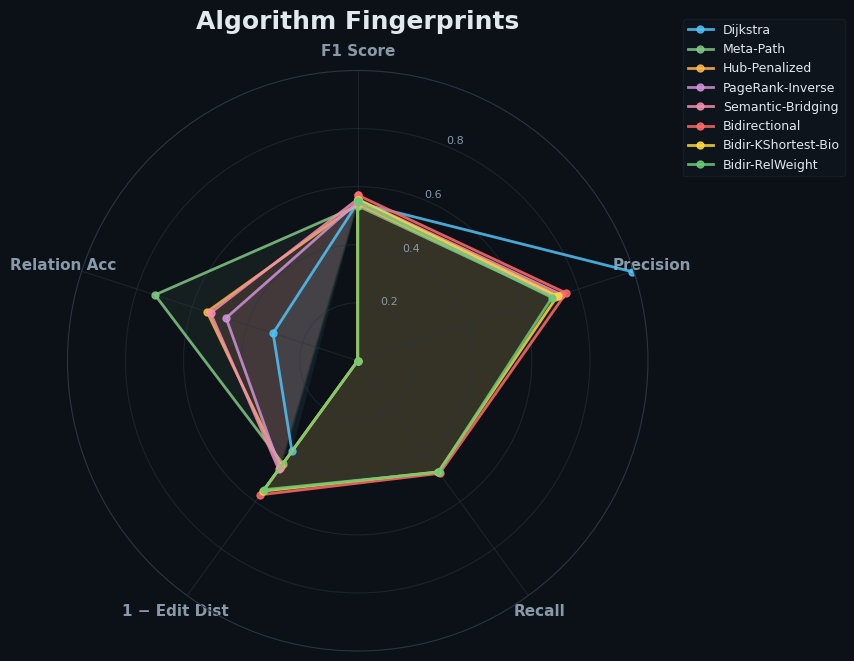

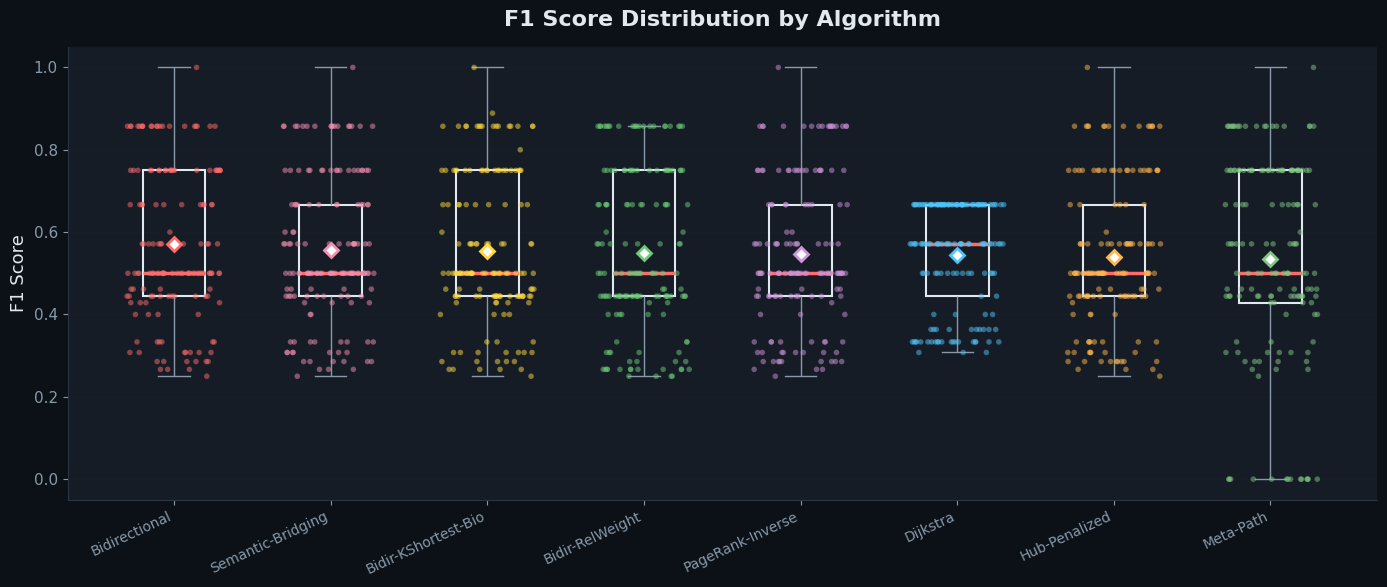

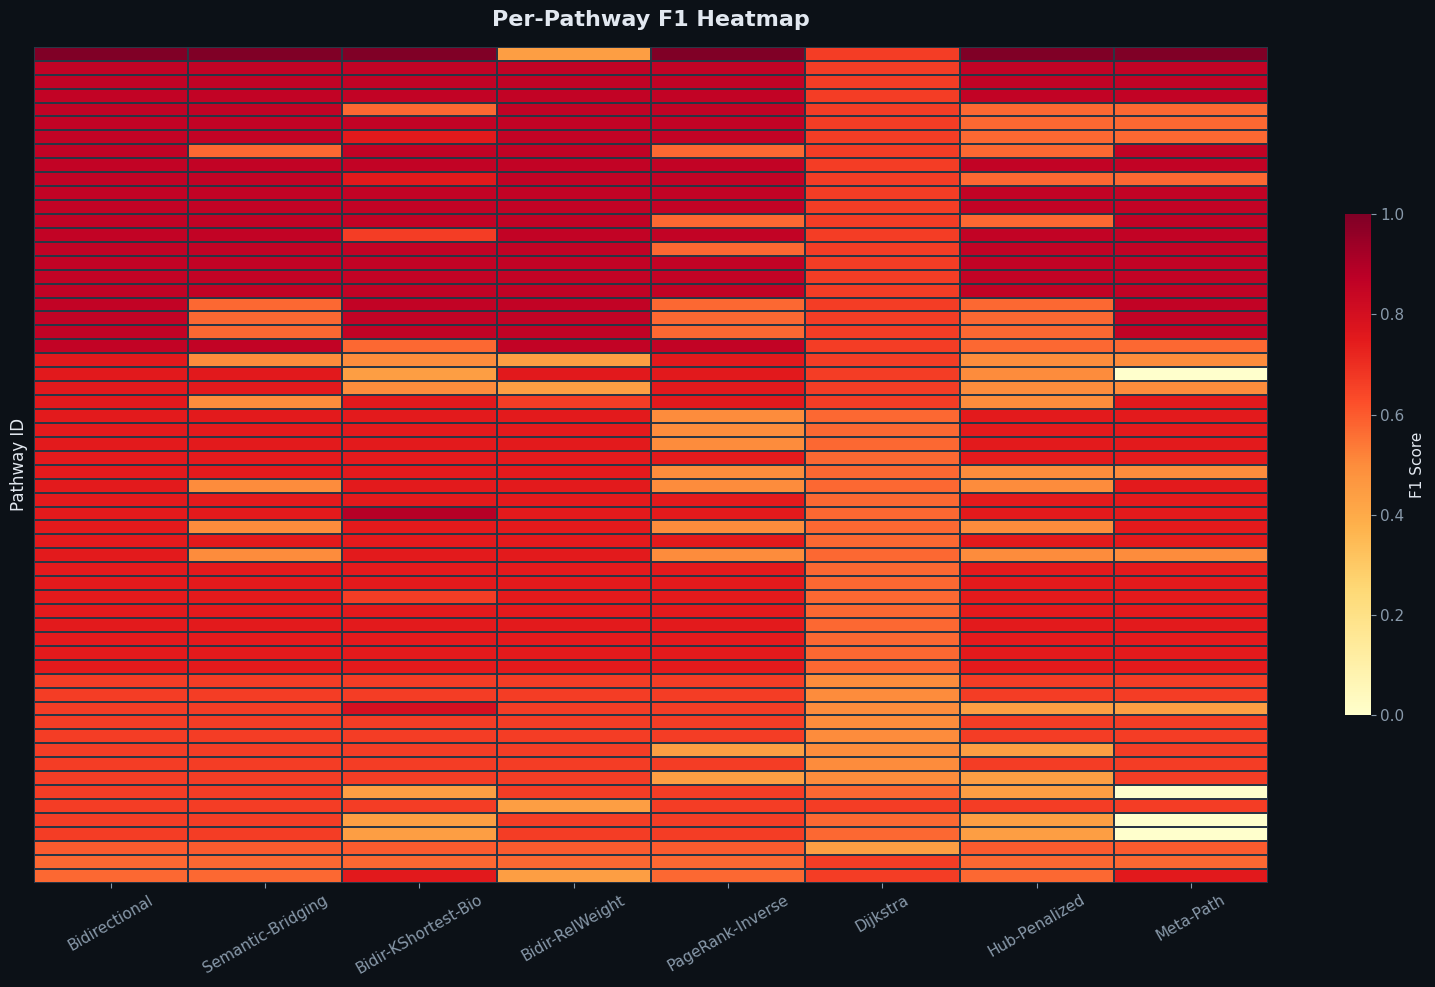

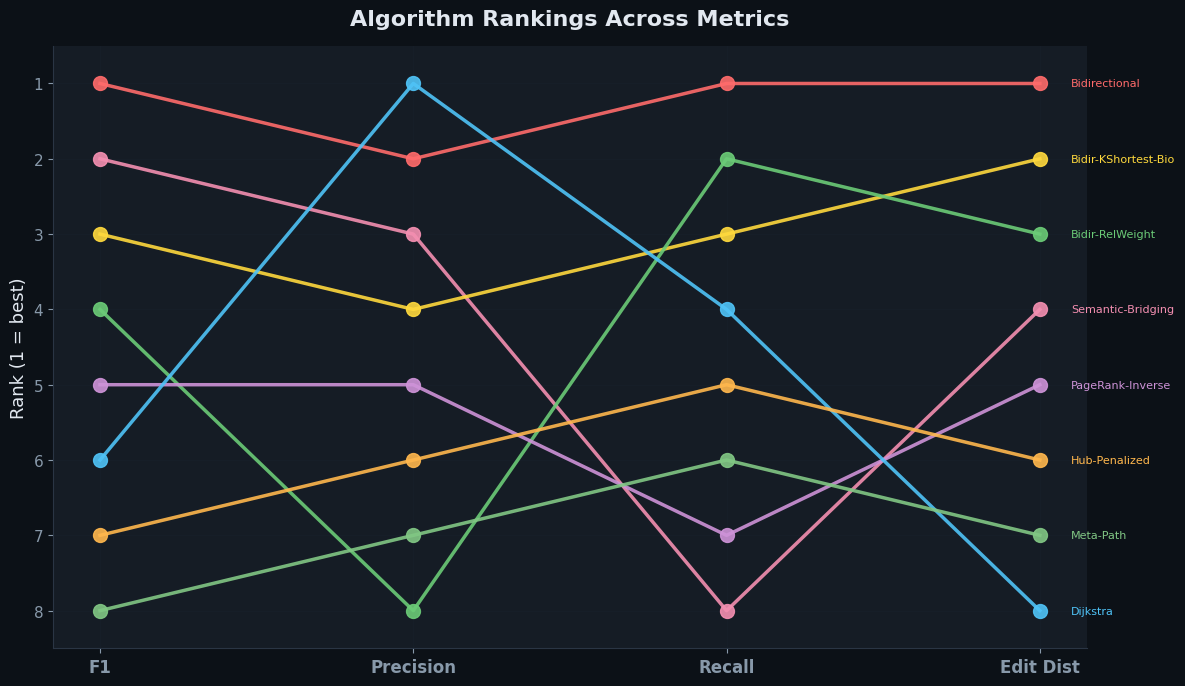

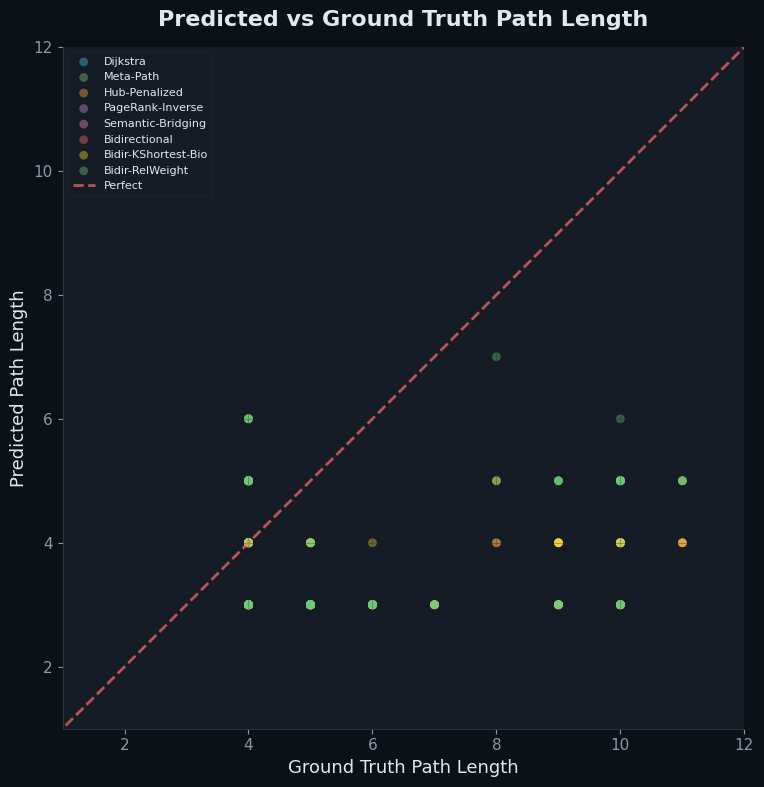

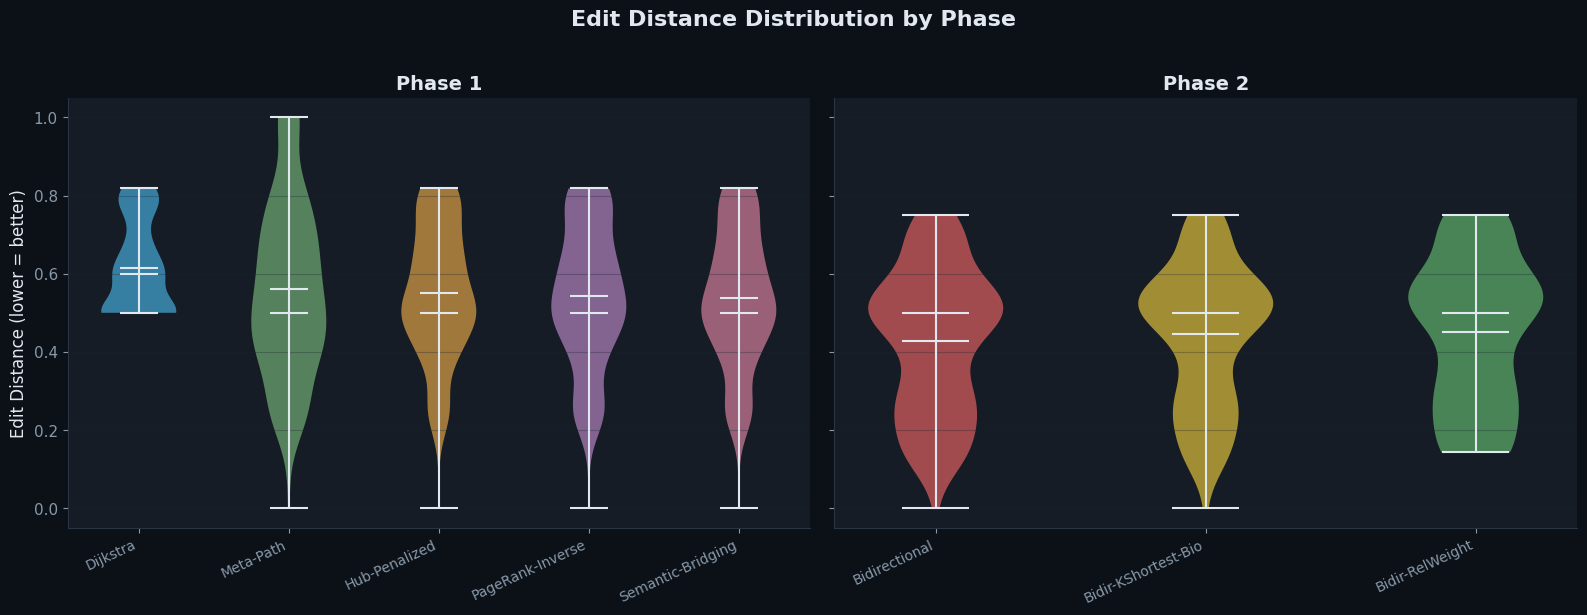

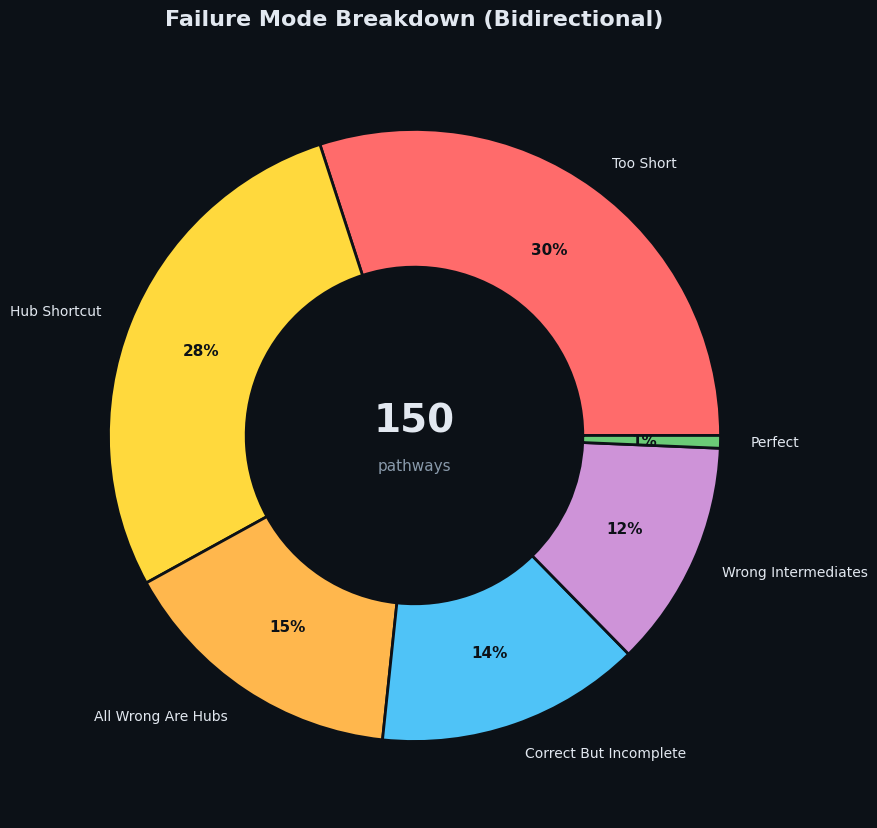

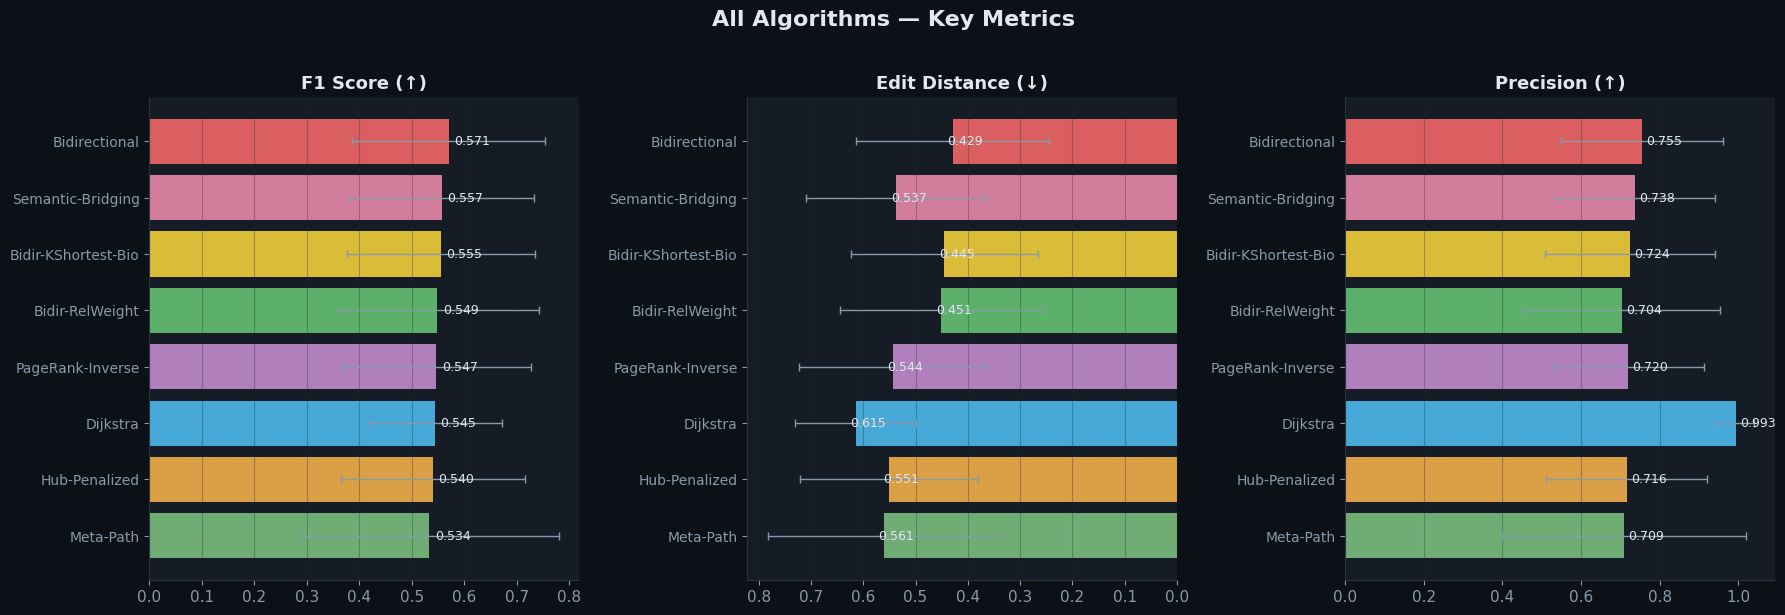

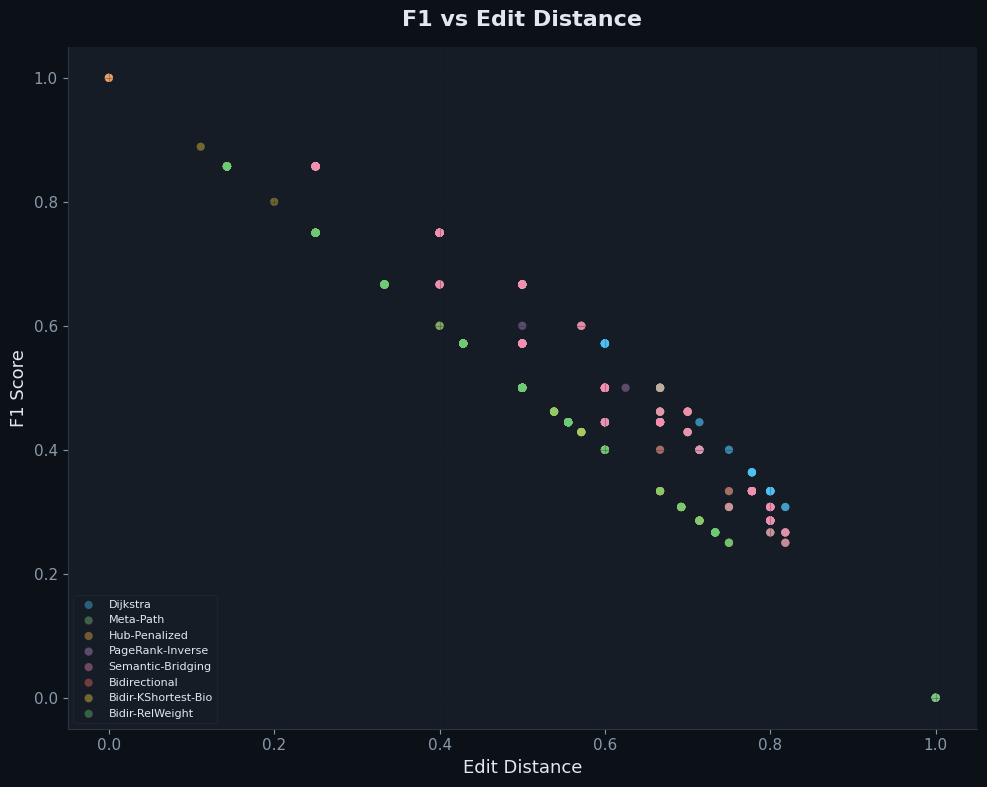

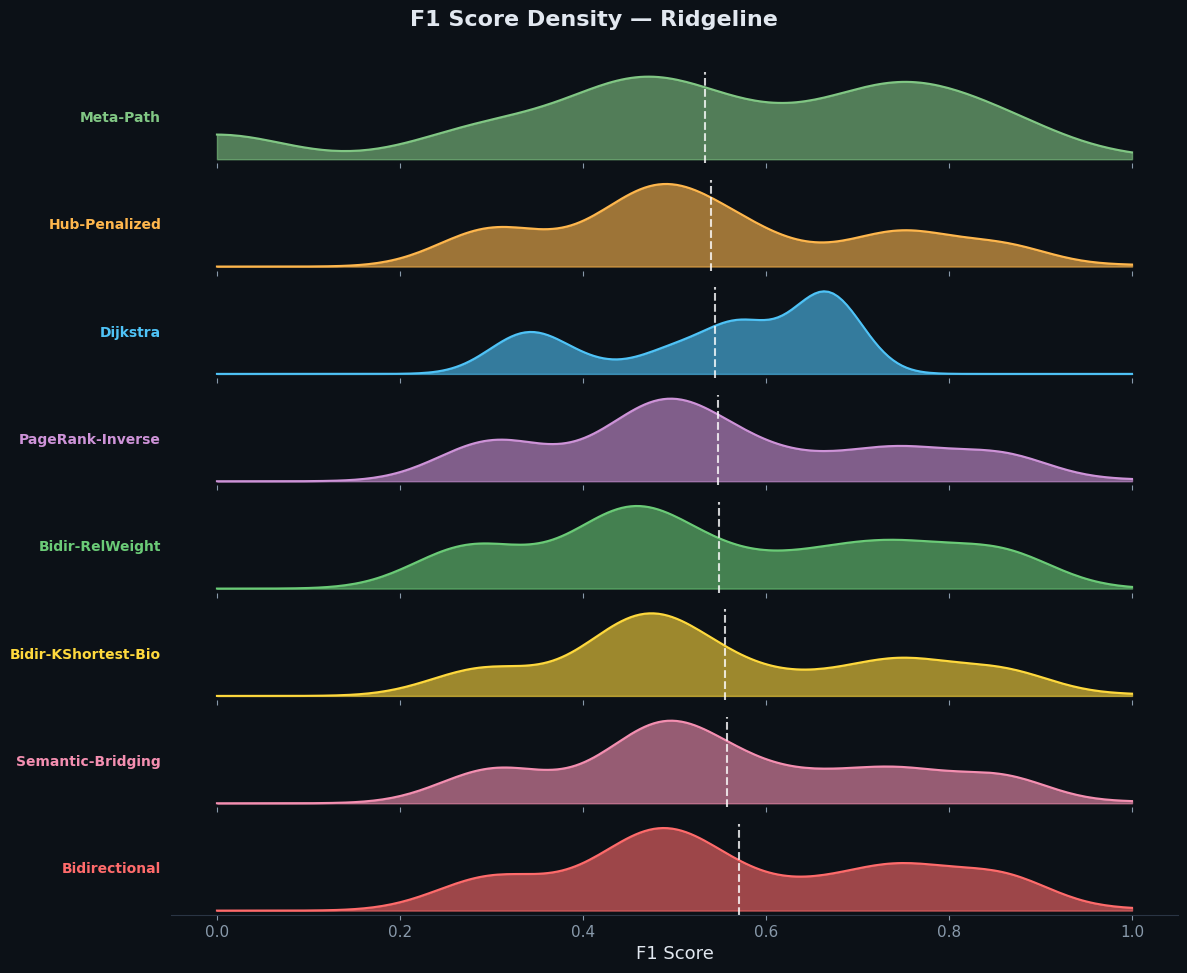

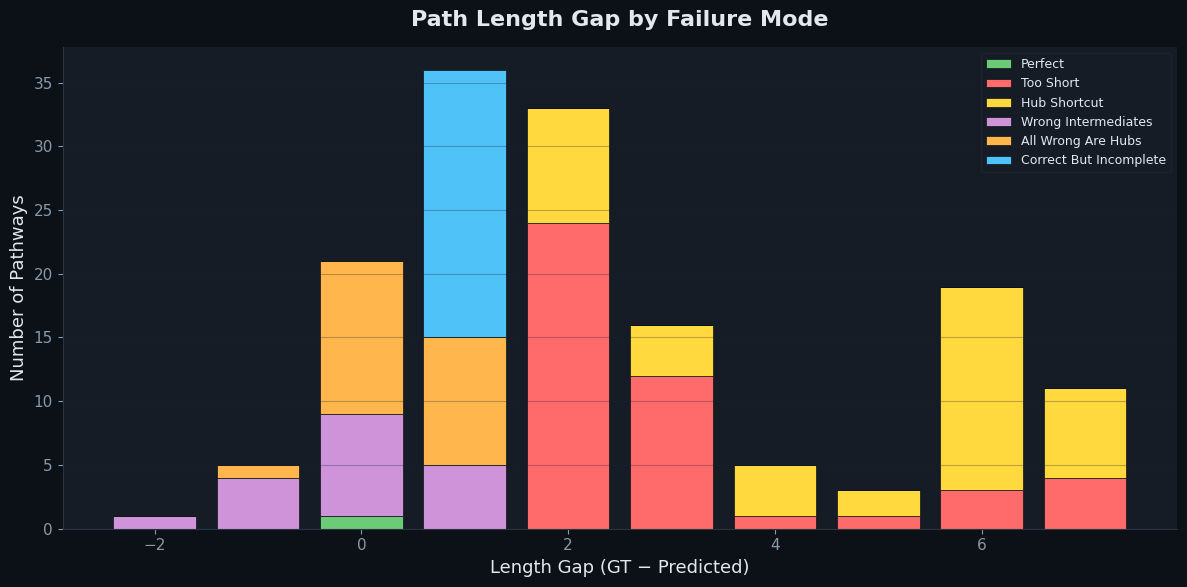

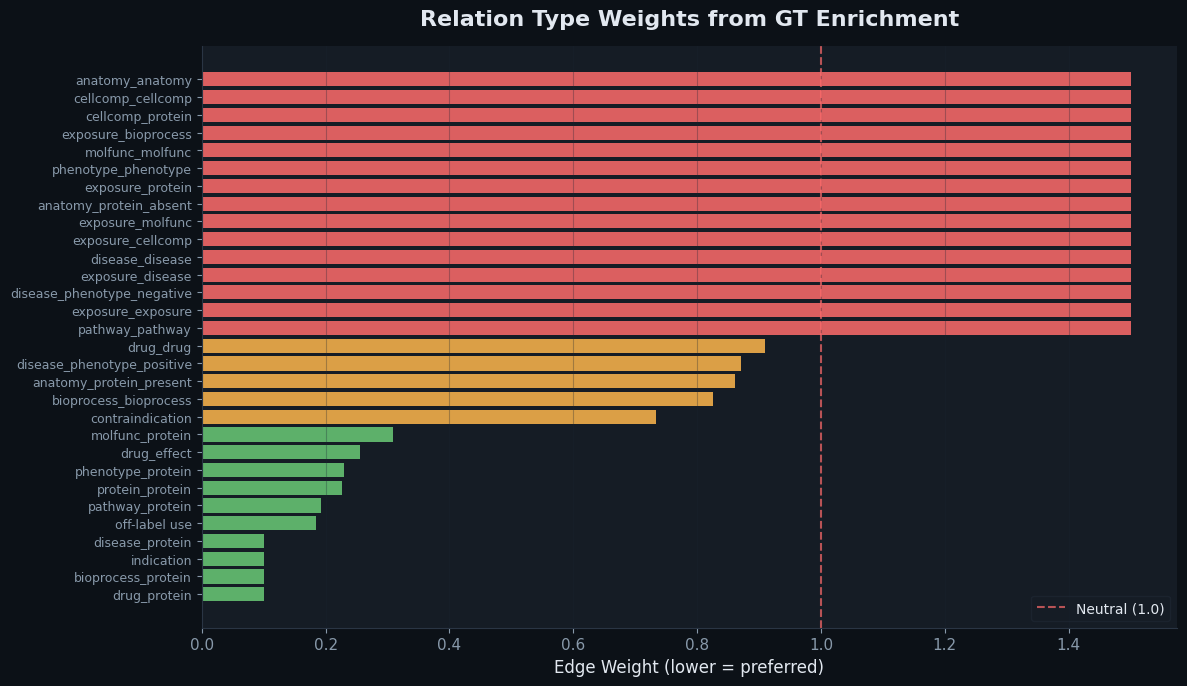

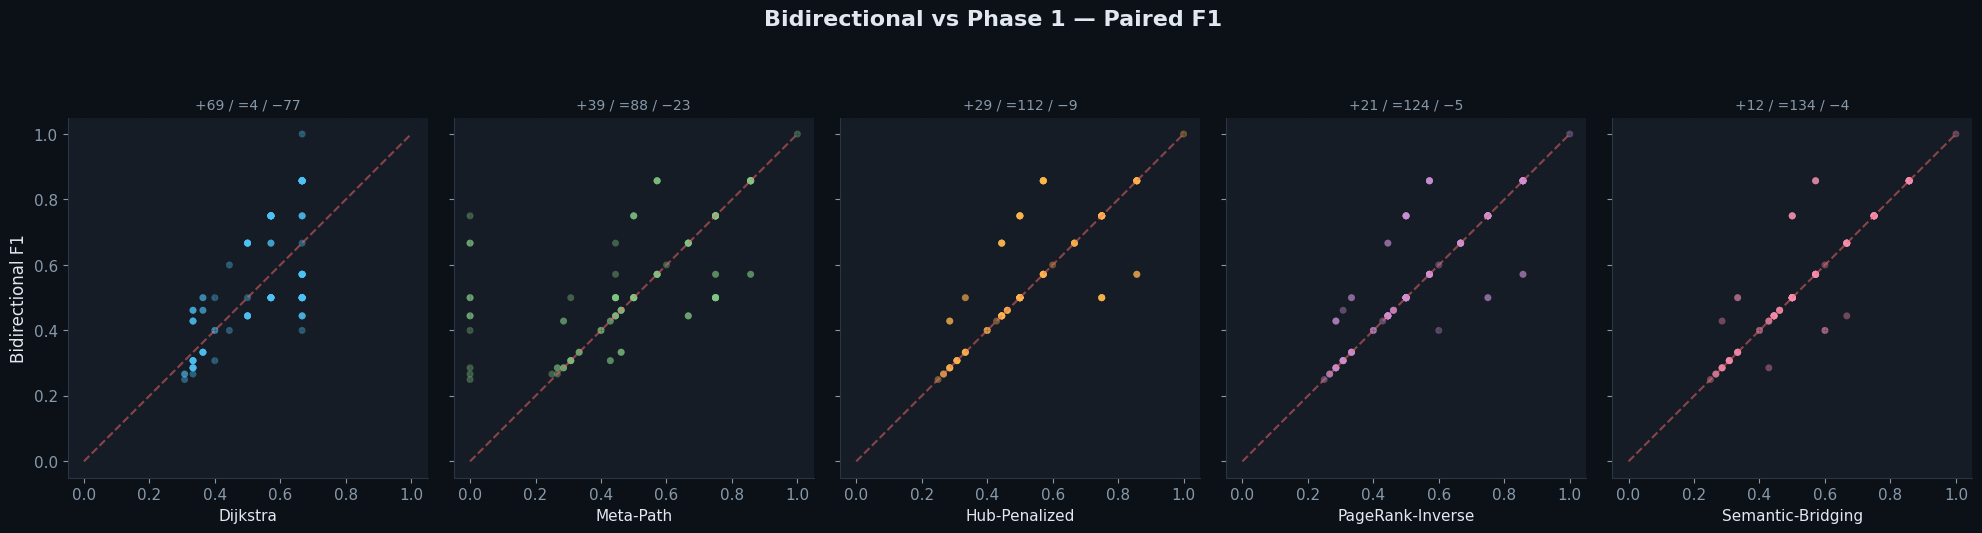

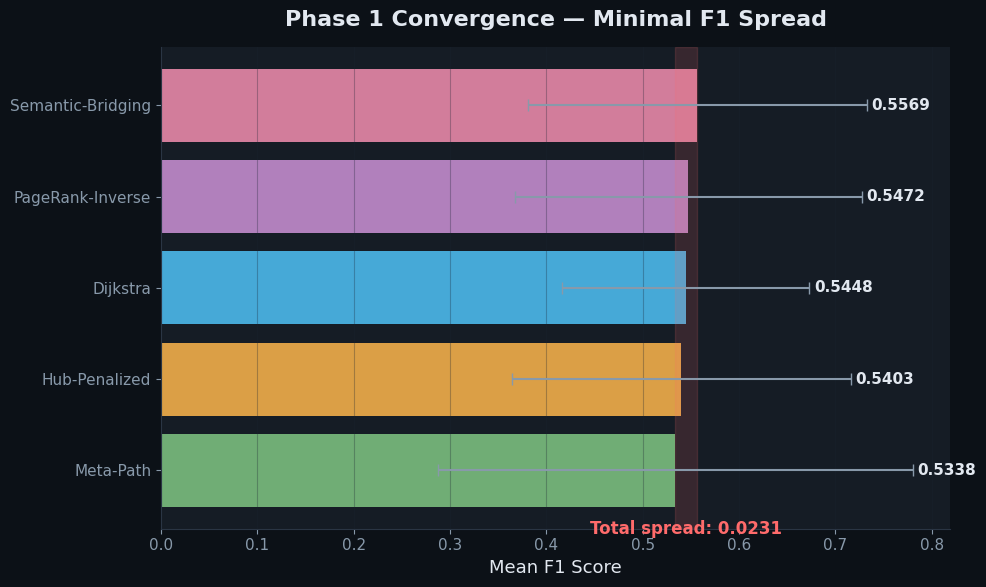

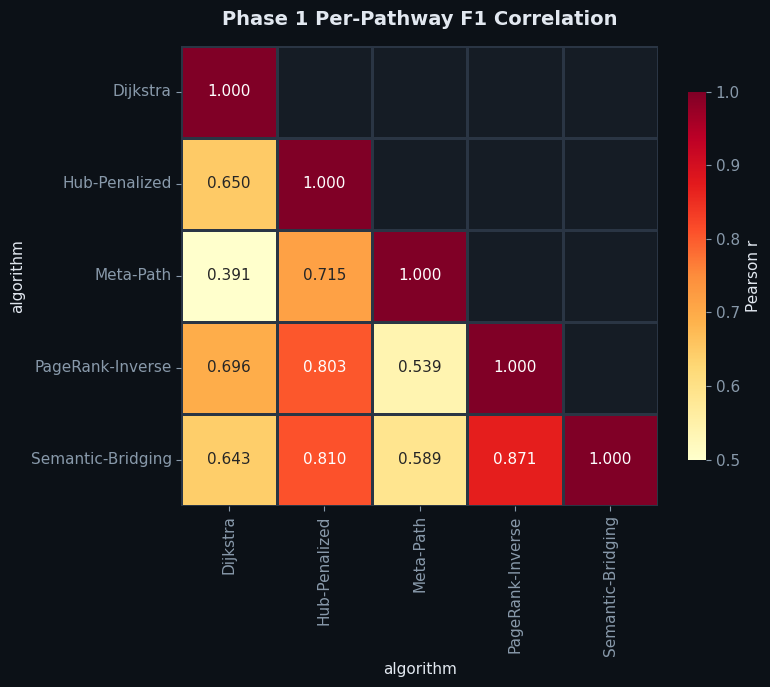

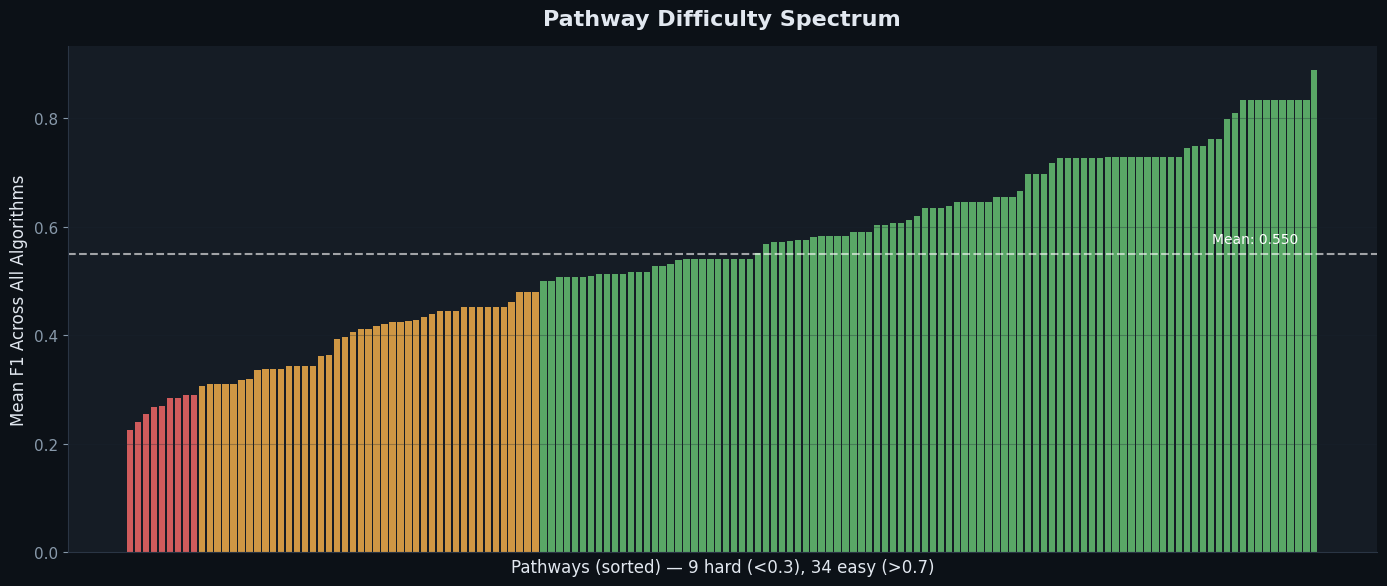

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


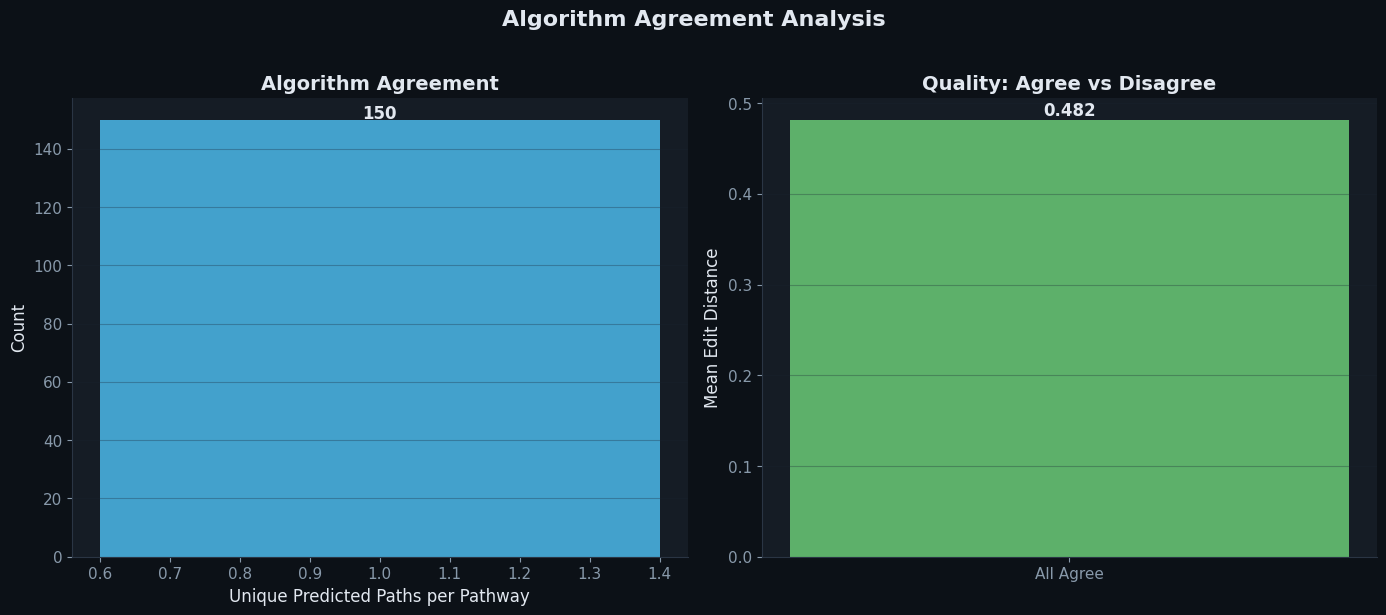

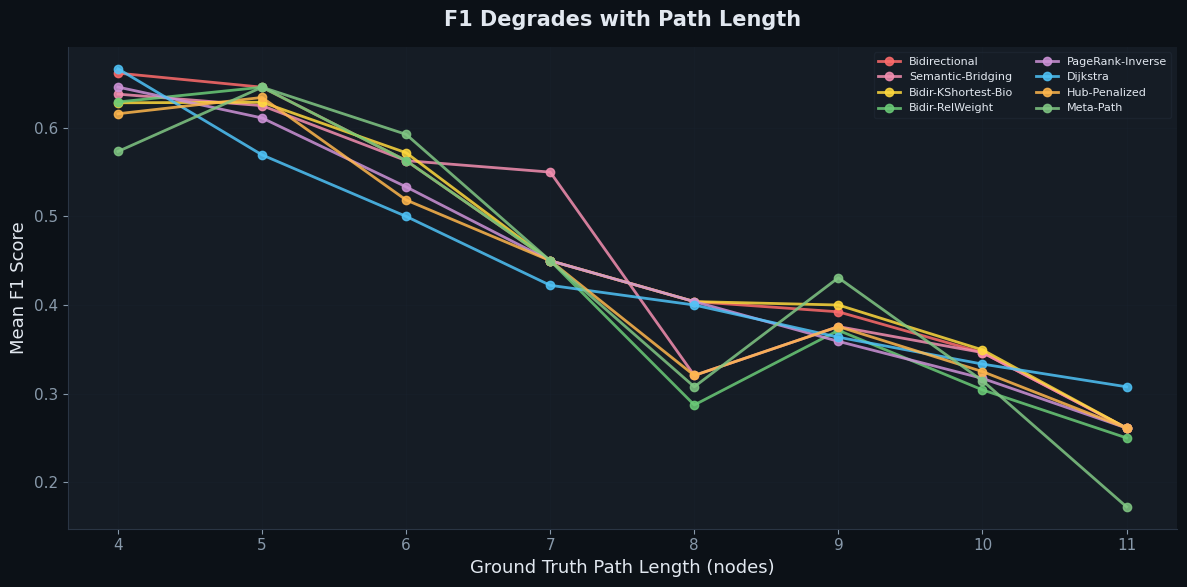

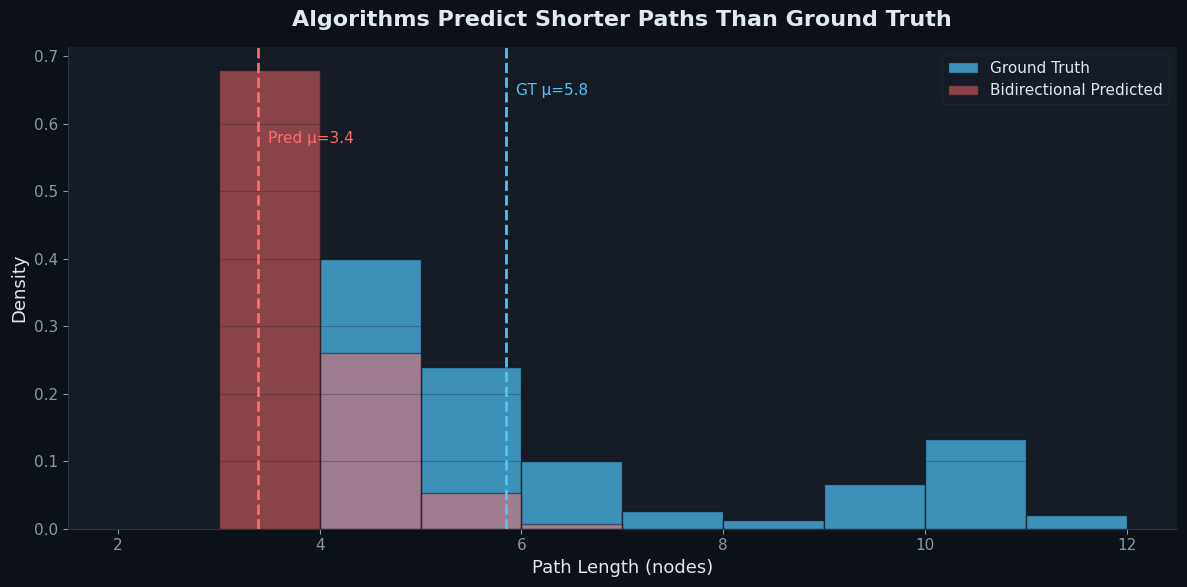

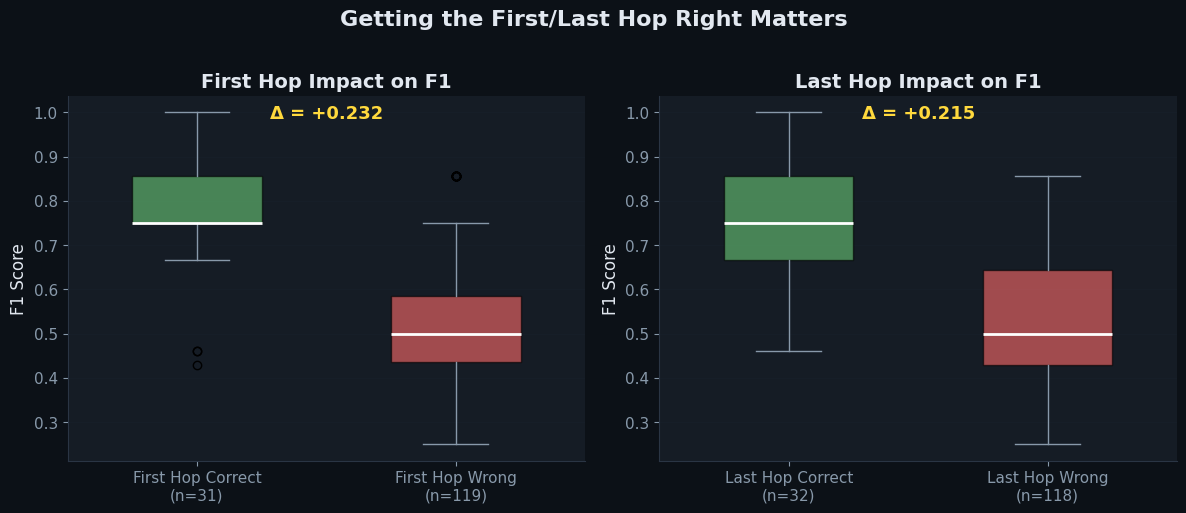

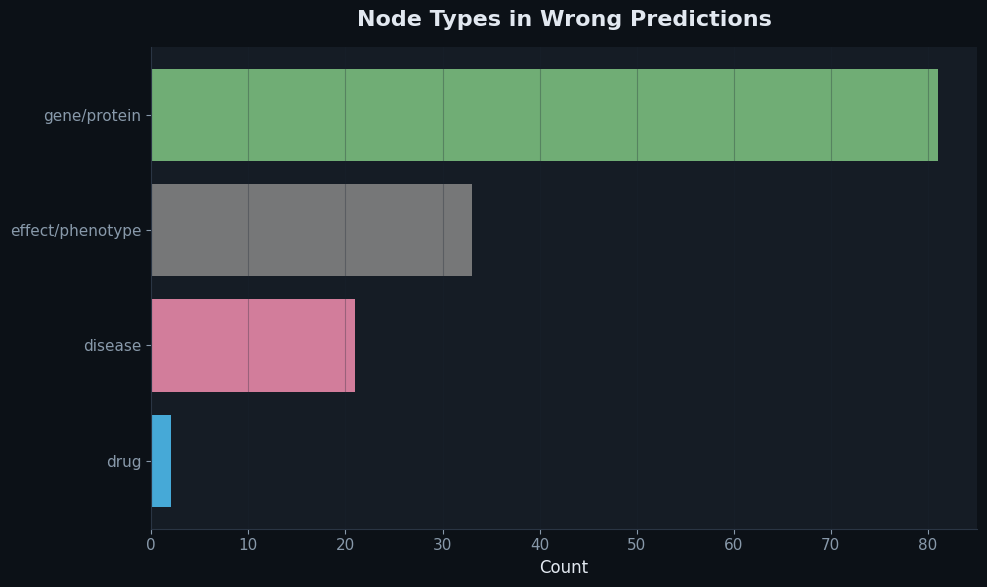

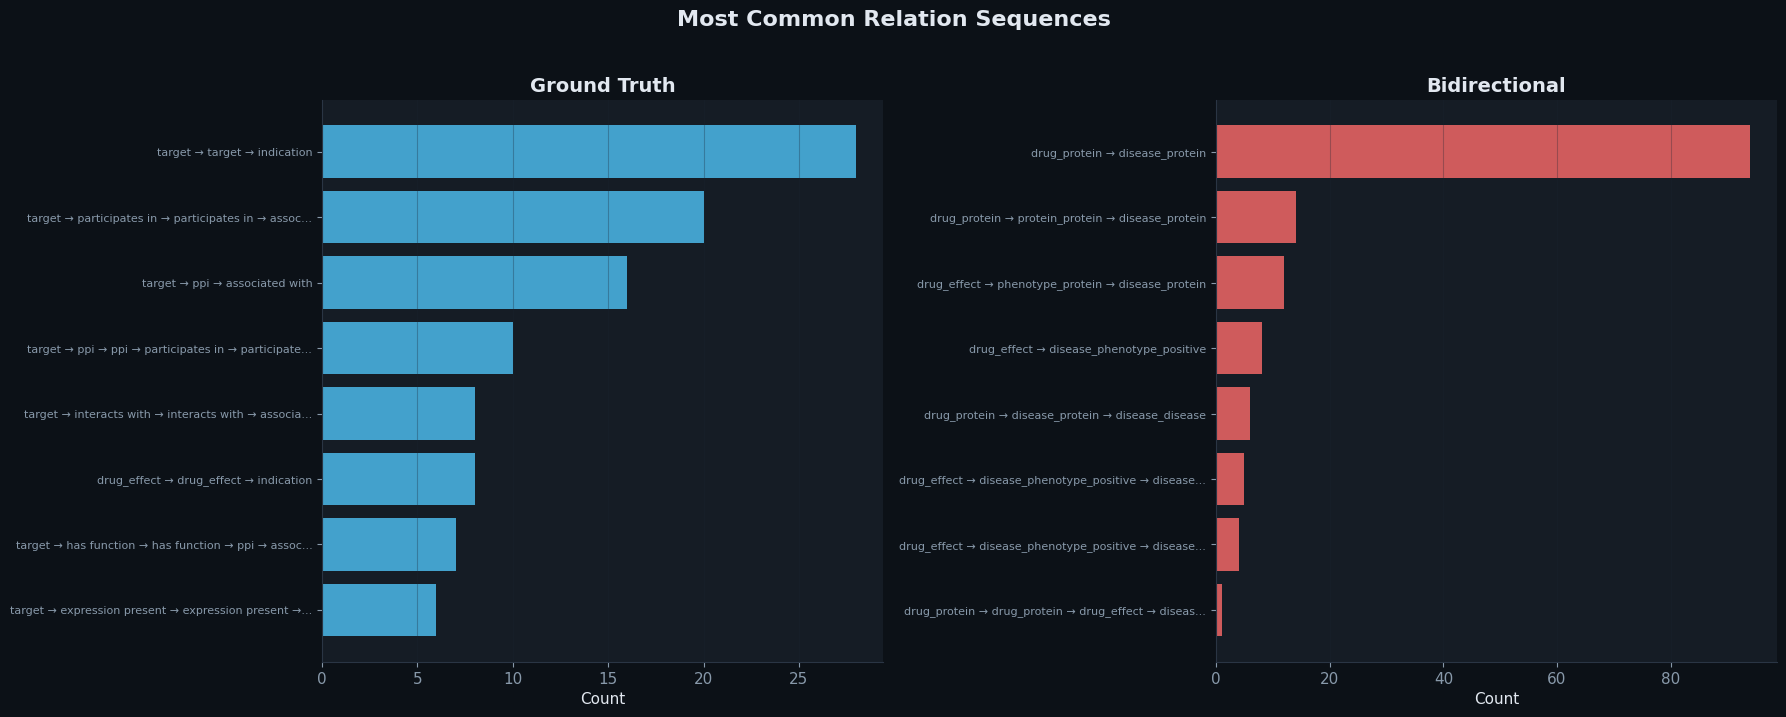

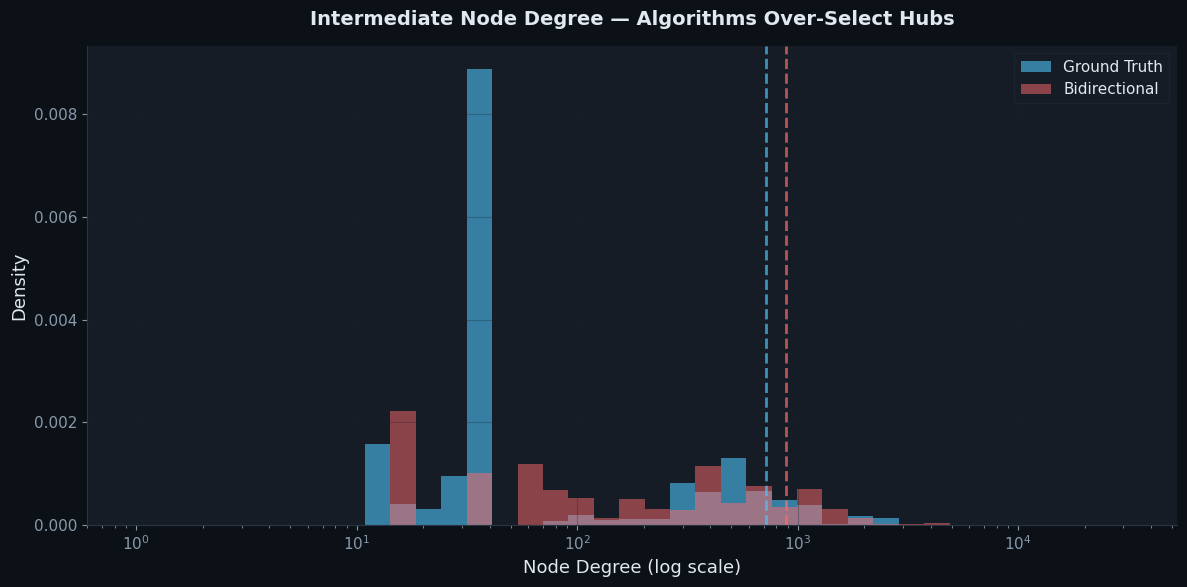

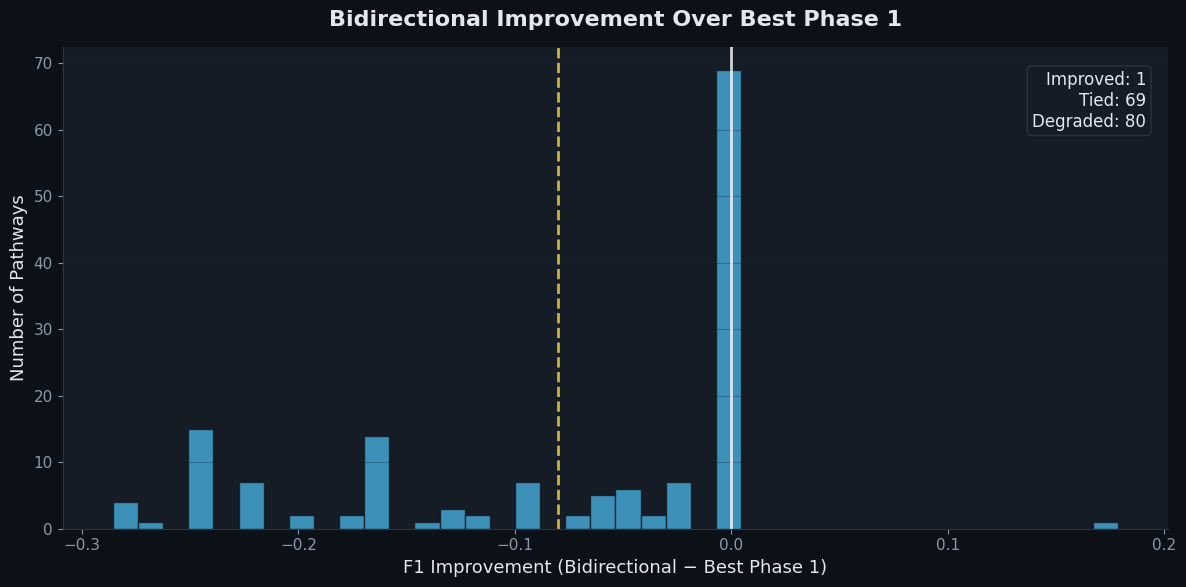

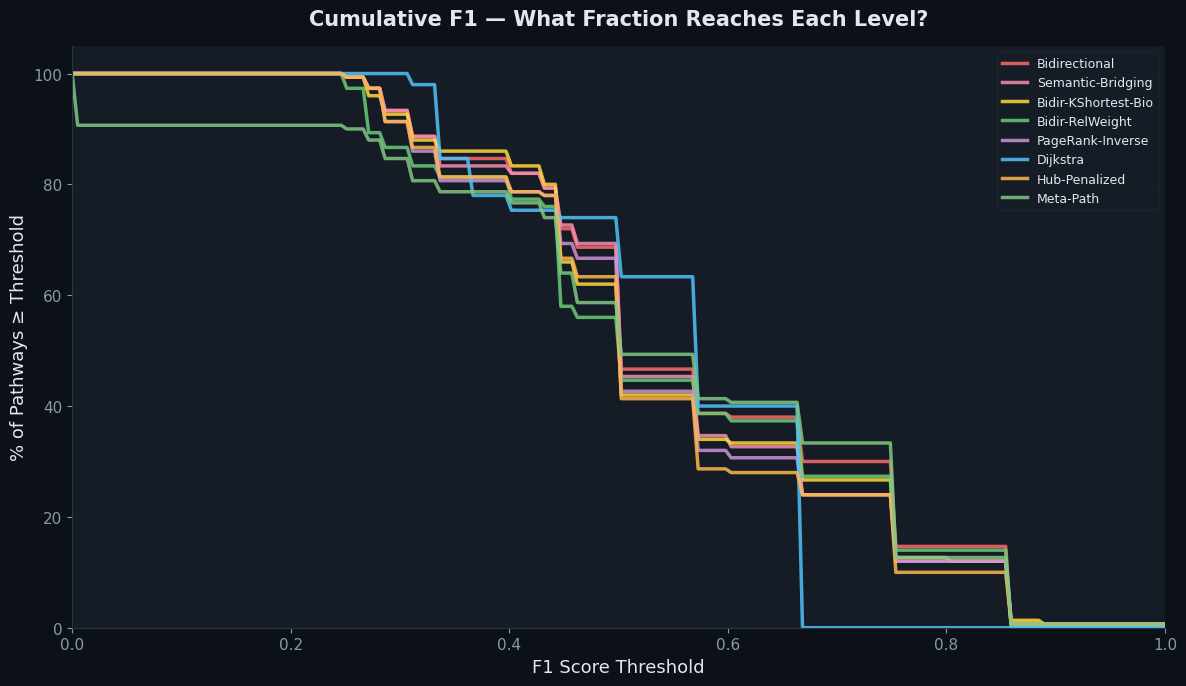


SAVED VISUALIZATIONS
  ✓ viz_01_*.png
  ✓ viz_02_*.png
  ✓ viz_03_*.png
  ✓ viz_04_*.png
  ✓ viz_05_*.png
  ✓ viz_06_*.png
  ✓ viz_07_*.png
  ✓ viz_08_*.png
  ✓ viz_09_*.png
  ✓ viz_10_*.png
  ✓ viz_11_*.png
  ✓ viz_12_*.png
  ✓ viz_13_*.png
  ✓ viz_14_*.png
  ✓ viz_15_*.png
  ✓ viz_16_*.png
  ✓ viz_17_*.png
  ✓ viz_18_*.png
  ✓ viz_19_*.png
  ✓ viz_20_*.png
  ✓ viz_21_*.png
  ✓ viz_22_*.png
  ✓ viz_23_*.png
  ✓ viz_24_*.png
  ✓ viz_25_*.png

  Total: 25 visualizations saved


In [ ]:
# ════════════════════════════════════════════════════════════════════
# COMPREHENSIVE VISUALIZATIONS
# ════════════════════════════════════════════════════════════════════

BG = '#0c1117'
CARD = '#151c25'
BORDER = '#2a3544'
TEXT = '#e2e8f0'
MUTED = '#8899aa'
GRID = '#1a2332'

matplotlib.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': CARD,
    'axes.edgecolor': BORDER,
    'axes.labelcolor': TEXT,
    'text.color': TEXT,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'grid.color': GRID,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = {
    'Dijkstra': '#4fc3f7',
    'Meta-Path': '#81c784',
    'Hub-Penalized': '#ffb74d',
    'PageRank-Inverse': '#ce93d8',
    'Semantic-Bridging': '#f48fb1',
    'Bidirectional': '#ff6b6b',
    'Bidir-KShortest-Bio': '#ffd93d',
    'Bidir-RelWeight': '#6bcb77',
}

mode_colors = {
    'perfect': '#6bcb77',
    'too_short': '#ff6b6b',
    'hub_shortcut': '#ffd93d',
    'all_wrong_are_hubs': '#ffb74d',
    'wrong_intermediates': '#ce93d8',
    'correct_but_incomplete': '#4fc3f7',
    'other': '#888888',
}

phase1_algos = ['Dijkstra', 'Meta-Path', 'Hub-Penalized', 'PageRank-Inverse', 'Semantic-Bridging']
phase2_algos = ['Bidirectional', 'Bidir-KShortest-Bio', 'Bidir-RelWeight']

all_bidir = pd.concat([
    bidir_results.assign(algorithm='Bidirectional'),
    bksb_results.assign(algorithm='Bidir-KShortest-Bio'),
    brw_results.assign(algorithm='Bidir-RelWeight'),
], ignore_index=True)

combined = pd.concat([results, all_bidir], ignore_index=True)
algo_order = combined.groupby('algorithm')['f1_score'].mean().sort_values(ascending=False).index.tolist()


# ════════════════════════════════════════════════════════════════════
# 1. RADAR — Algorithm Fingerprints
# ════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

algo_radar = {}
for algo in combined['algorithm'].unique():
    sub = combined[combined['algorithm'] == algo]
    vals = [sub['f1_score'].mean(), sub['precision'].mean(), sub['recall'].mean(),
            1 - sub['edit_distance'].mean()]
    if algo in results['algorithm'].unique():
        rsub = results[results['algorithm'] == algo]
        vals.append(rsub['relation_accuracy'].mean() if 'relation_accuracy' in rsub.columns and rsub['relation_accuracy'].notna().any() else 0)
    else:
        vals.append(0)
    algo_radar[algo] = vals

labels = ['F1 Score', 'Precision', 'Recall', '1 − Edit Dist', 'Relation Acc']
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8'], fontsize=8, color=MUTED)
ax.grid(color=BORDER, alpha=0.5)
for algo, vals in algo_radar.items():
    v = vals + vals[:1]
    color = COLORS.get(algo, '#888')
    ax.plot(angles, v, 'o-', linewidth=2, label=algo, color=color, markersize=5, alpha=0.85)
    ax.fill(angles, v, alpha=0.08, color=color)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9, framealpha=0.3,
          facecolor=CARD, edgecolor=BORDER, labelcolor=TEXT)
ax.set_title('Algorithm Fingerprints', fontsize=18, fontweight='bold', pad=30, color=TEXT)
plt.tight_layout()
plt.savefig('viz_01_radar.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()


# ════════════════════════════════════════════════════════════════════
# 2. STRIP + BOX — F1 Distribution
# ════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 6))
palette = {a: COLORS.get(a, '#888') for a in algo_order}
sns.stripplot(data=combined, x='algorithm', y='f1_score', order=algo_order,
              palette=palette, alpha=0.5, jitter=0.3, size=4, ax=ax)
sns.boxplot(data=combined, x='algorithm', y='f1_score', order=algo_order,
            boxprops=dict(facecolor='none', edgecolor=TEXT, linewidth=1.5),
            whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
            medianprops=dict(color='#ff6b6b', linewidth=2.5), fliersize=0, width=0.4, ax=ax)
for i, algo in enumerate(algo_order):
    mean_val = combined[combined['algorithm'] == algo]['f1_score'].mean()
    ax.plot(i, mean_val, 'D', color='white', markersize=7, zorder=5,
            markeredgecolor=COLORS.get(algo, '#888'), markeredgewidth=2)
ax.set_xlabel('')
ax.set_ylabel('F1 Score', fontsize=13)
ax.set_title('F1 Score Distribution by Algorithm', fontsize=16, fontweight='bold', pad=15)
ax.set_xticklabels(algo_order, rotation=25, ha='right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('viz_02_f1_distribution.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()


# ════════════════════════════════════════════════════════════════════
# 3. HEATMAP — Per-Pathway F1
# ════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(16, 10))
pivot = combined.pivot_table(index='pathway_id', columns='algorithm', values='f1_score')
pivot = pivot[algo_order].sort_values(algo_order[0], ascending=False)
if len(pivot) > 60:
    pivot = pivot.iloc[:60]
sns.heatmap(pivot, cmap='YlOrRd', vmin=0, vmax=1, ax=ax, linewidths=0.3, linecolor=BORDER,
            cbar_kws={'label': 'F1 Score', 'shrink': 0.6},
            yticklabels=True if len(pivot) <= 40 else False)
ax.set_title('Per-Pathway F1 Heatmap', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Pathway ID', fontsize=12)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('viz_03_pathway_heatmap.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()


# ════════════════════════════════════════════════════════════════════
# 4. BUMP CHART — Rank by Metric
# ════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 7))
rank_metrics = {'F1': ('f1_score', False), 'Precision': ('precision', False),
                'Recall': ('recall', False), 'Edit Dist': ('edit_distance', True)}
rank_data = {}
for label, (col, asc) in rank_metrics.items():
    means = combined.groupby('algorithm')[col].mean().sort_values(ascending=asc)
    for rank, algo in enumerate(means.index, 1):
        rank_data.setdefault(algo, {})[label] = rank
metric_labels = list(rank_metrics.keys())
x_pos = np.arange(len(metric_labels))
for algo, ranks in rank_data.items():
    y = [ranks[m] for m in metric_labels]
    color = COLORS.get(algo, '#888')
    ax.plot(x_pos, y, 'o-', color=color, linewidth=2.5, markersize=10, label=algo, alpha=0.9)
    ax.annotate(algo, (x_pos[-1] + 0.1, y[-1]), fontsize=8, color=color, va='center')
ax.set_xticks(x_pos)
ax.set_xticklabels(metric_labels, fontsize=12, fontweight='bold')
ax.set_ylabel('Rank (1 = best)', fontsize=13)
ax.set_ylim(len(combined['algorithm'].unique()) + 0.5, 0.5)
ax.set_yticks(range(1, len(combined['algorithm'].unique()) + 1))
ax.grid(axis='both', alpha=0.3)
ax.set_title('Algorithm Rankings Across Metrics', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('viz_04_bump_chart.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()


# ════════════════════════════════════════════════════════════════════
# 5. SCATTER — Predicted vs GT Length
# ════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 8))
for algo in combined['algorithm'].unique():
    sub = combined[combined['algorithm'] == algo]
    ax.scatter(sub['gt_length'], sub['pred_length'], alpha=0.4, s=40,
               color=COLORS.get(algo, '#888'), label=algo, edgecolors='none')
max_len = max(combined['gt_length'].max(), combined['pred_length'].max()) + 1
ax.plot([0, max_len], [0, max_len], '--', color='#ff6b6b', linewidth=2, alpha=0.7, label='Perfect')
ax.set_xlabel('Ground Truth Path Length', fontsize=13)
ax.set_ylabel('Predicted Path Length', fontsize=13)
ax.set_title('Predicted vs Ground Truth Path Length', fontsize=16, fontweight='bold', pad=15)
ax.legend(fontsize=8, framealpha=0.3, facecolor=CARD, edgecolor=BORDER, labelcolor=TEXT)
ax.set_aspect('equal')
ax.set_xlim(1, max_len)
ax.set_ylim(1, max_len)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('viz_05_length_scatter.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()


# ════════════════════════════════════════════════════════════════════
# 6. VIOLIN — Edit Distance by Phase
# ════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, (name, algos) in zip(axes, [('Phase 1', phase1_algos), ('Phase 2', phase2_algos)]):
    phase_data = combined[combined['algorithm'].isin(algos)]
    order = [a for a in algos if a in phase_data['algorithm'].unique()]
    parts = ax.violinplot([phase_data[phase_data['algorithm'] == a]['edit_distance'].values for a in order],
                          positions=range(len(order)), showmeans=True, showmedians=True)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(COLORS.get(order[i], '#888'))
        pc.set_alpha(0.6)
    for key in ['cmeans', 'cmedians', 'cbars', 'cmins', 'cmaxes']:
        if key in parts:
            parts[key].set_color(TEXT)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=25, ha='right', fontsize=10)
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel('Edit Distance (lower = better)', fontsize=12)
plt.suptitle('Edit Distance Distribution by Phase', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_06_violin_edit.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()


# ════════════════════════════════════════════════════════════════════
# 7. DONUT — Failure Modes
# ════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(9, 9))
mc = fdf['mode'].value_counts()
wedges, texts, autotexts = ax.pie(
    mc.values, labels=[m.replace('_', ' ').title() for m in mc.index],
    colors=[mode_colors.get(m, '#888') for m in mc.index], autopct='%1.0f%%',
    pctdistance=0.75, labeldistance=1.1,
    wedgeprops=dict(width=0.45, edgecolor=BG, linewidth=2),
    textprops=dict(color=TEXT, fontsize=10))
for at in autotexts:
    at.set_color('#0c1117')
    at.set_fontweight('bold')
    at.set_fontsize(11)
ax.add_artist(plt.Circle((0, 0), 0.55, fc=BG))
ax.text(0, 0.05, f'{len(fdf)}', ha='center', va='center', fontsize=28, fontweight='bold', color=TEXT)
ax.text(0, -0.1, 'pathways', ha='center', va='center', fontsize=11, color=MUTED)
ax.set_title('Failure Mode Breakdown (Bidirectional)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('viz_07_failure_donut.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()


# ════════════════════════════════════════════════════════════════════
# 8. HORIZONTAL BAR — All Algos, 3 Metrics
# ════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (metric, title, inv) in zip(axes, [('f1_score', 'F1 Score (↑)', False),
        ('edit_distance', 'Edit Distance (↓)', True), ('precision', 'Precision (↑)', False)]):
    means = combined.groupby('algorithm')[metric].mean().reindex(algo_order)
    stds = combined.groupby('algorithm')[metric].std().reindex(algo_order)
    ax.barh(range(len(algo_order)), means.values, xerr=stds.values,
            color=[COLORS.get(a, '#888') for a in algo_order], alpha=0.85,
            error_kw=dict(ecolor=MUTED, capsize=3, linewidth=1))
    for i, val in enumerate(means.values):
        ax.text(val + 0.01, i, f'{val:.3f}', va='center', fontsize=9, color=TEXT)
    ax.set_yticks(range(len(algo_order)))
    ax.set_yticklabels(algo_order, fontsize=10)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()
    if inv:
        ax.invert_xaxis()
plt.suptitle('All Algorithms — Key Metrics', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_08_metrics_comparison.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()


# ════════════════════════════════════════════════════════════════════
# 9. SCATTER — F1 vs Edit Distance
# ════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 8))
for algo in combined['algorithm'].unique():
    sub = combined[combined['algorithm'] == algo]
    ax.scatter(sub['edit_distance'], sub['f1_score'], alpha=0.4, s=35,
               color=COLORS.get(algo, '#888'), label=algo, edgecolors='none')
ax.set_xlabel('Edit Distance', fontsize=13)
ax.set_ylabel('F1 Score', fontsize=13)
ax.set_title('F1 vs Edit Distance', fontsize=16, fontweight='bold', pad=15)
ax.legend(fontsize=8, framealpha=0.3, facecolor=CARD, edgecolor=BORDER, labelcolor=TEXT, loc='lower left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('viz_09_f1_vs_edit.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()


# ════════════════════════════════════════════════════════════════════
# 10. RIDGELINE — F1 Density
# ════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(len(algo_order), 1, figsize=(12, len(algo_order) * 1.2), sharex=True)
for i, algo in enumerate(reversed(algo_order)):
    ax = axes[i]
    sub = combined[combined['algorithm'] == algo]['f1_score'].dropna()
    color = COLORS.get(algo, '#888')
    if len(sub) > 5:
        try:
            kde = gaussian_kde(sub, bw_method=0.3)
            x = np.linspace(0, 1, 200)
            y = kde(x)
            ax.fill_between(x, y, alpha=0.6, color=color)
            ax.plot(x, y, color=color, linewidth=1.5)
        except Exception:
            ax.hist(sub, bins=20, color=color, alpha=0.6, density=True)
    ax.axvline(sub.mean(), color='white', linewidth=1.5, linestyle='--', alpha=0.8)
    ax.set_ylabel('')
    ax.set_yticks([])
    ax.text(-0.01, 0.5, algo, transform=ax.transAxes, ha='right', va='center',
            fontsize=10, fontweight='bold', color=color)
    ax.set_facecolor(BG)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
axes[-1].set_xlabel('F1 Score', fontsize=13)
axes[-1].spines['bottom'].set_visible(True)
fig.suptitle('F1 Score Density — Ridgeline', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_10_ridgeline.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()


# ════════════════════════════════════════════════════════════════════
# 11. STACKED BAR — Length Gap by Failure Mode
# ════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 6))
gd = fdf.copy()
gd['lg'] = gd['length_gap'].astype(int)
gm = gd.groupby(['lg', 'mode']).size().unstack(fill_value=0)
mo = [m for m in ['perfect', 'too_short', 'hub_shortcut', 'wrong_intermediates',
      'all_wrong_are_hubs', 'correct_but_incomplete', 'other'] if m in gm.columns]
gm = gm[mo]
bottom = np.zeros(len(gm))
for mode in mo:
    ax.bar(gm.index, gm[mode], bottom=bottom, color=mode_colors.get(mode, '#888'),
           label=mode.replace('_', ' ').title(), edgecolor=BG, linewidth=0.5)
    bottom += gm[mode].values
ax.set_xlabel('Length Gap (GT − Predicted)', fontsize=13)
ax.set_ylabel('Number of Pathways', fontsize=13)
ax.set_title('Path Length Gap by Failure Mode', fontsize=16, fontweight='bold', pad=15)
ax.legend(fontsize=9, framealpha=0.3, facecolor=CARD, edgecolor=BORDER, labelcolor=TEXT)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('viz_11_length_gap.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()


# ════════════════════════════════════════════════════════════════════
# 12. RELATION WEIGHTS
# ════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 7))
rw_sorted = sorted(relation_weights.items(), key=lambda x: x[1])
rn = [r[0] for r in rw_sorted]
rv = [r[1] for r in rw_sorted]
rc = ['#6bcb77' if v < 0.5 else '#ffb74d' if v < 1.0 else '#ff6b6b' for v in rv]
ax.barh(range(len(rn)), rv, color=rc, alpha=0.85, edgecolor='none')
ax.axvline(1.0, color='#ff6b6b', linewidth=1.5, linestyle='--', alpha=0.7, label='Neutral (1.0)')
ax.set_yticks(range(len(rn)))
ax.set_yticklabels(rn, fontsize=9)
ax.set_xlabel('Edge Weight (lower = preferred)', fontsize=12)
ax.set_title('Relation Type Weights from GT Enrichment', fontsize=16, fontweight='bold', pad=15)
ax.legend(fontsize=10, framealpha=0.3, facecolor=CARD, edgecolor=BORDER, labelcolor=TEXT)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('viz_12_relation_weights.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()


# ════════════════════════════════════════════════════════════════════
# 13. PAIRED — Bidirectional vs Each Phase 1
# ════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, len(phase1_algos), figsize=(4 * len(phase1_algos), 5), sharey=True)
for ax, p1 in zip(axes, phase1_algos):
    d1 = results[results['algorithm'] == p1][['pathway_id', 'f1_score']].rename(columns={'f1_score': 'p1'})
    d2 = bidir_results[['pathway_id', 'f1_score']].rename(columns={'f1_score': 'bi'})
    pr = d1.merge(d2, on='pathway_id')
    imp = (pr['bi'] > pr['p1'] + 0.01).sum()
    deg = (pr['bi'] < pr['p1'] - 0.01).sum()
    tie = len(pr) - imp - deg
    ax.scatter(pr['p1'], pr['bi'], alpha=0.4, s=25, color=COLORS.get(p1, '#888'), edgecolors='none')
    ax.plot([0, 1], [0, 1], '--', color='#ff6b6b', alpha=0.5, linewidth=1.5)
    ax.set_xlabel(p1, fontsize=11)
    ax.set_title(f'+{imp} / ={tie} / −{deg}', fontsize=10, color=MUTED)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect('equal')
    ax.grid(alpha=0.2)
axes[0].set_ylabel('Bidirectional F1', fontsize=12)
fig.suptitle('Bidirectional vs Phase 1 — Paired F1', fontsize=16, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('viz_13_paired_improvement.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()


# ════════════════════════════════════════════════════════════════════
# 14. PHASE 1 CONVERGENCE
# ════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 6))
p1d = results[results['algorithm'].isin(phase1_algos)]
p1m = p1d.groupby('algorithm')['f1_score'].mean().sort_values(ascending=False)
p1s = p1d.groupby('algorithm')['f1_score'].std()
spread = p1m.max() - p1m.min()
for i, (algo, mean) in enumerate(p1m.items()):
    ax.barh(i, mean, xerr=p1s[algo], color=COLORS.get(algo, '#888'), alpha=0.85,
            error_kw=dict(ecolor=MUTED, capsize=4, linewidth=1.5))
    ax.text(mean + p1s[algo] + 0.005, i, f'{mean:.4f}', va='center', fontsize=11, color=TEXT, fontweight='bold')
ax.axvspan(p1m.min(), p1m.max(), alpha=0.15, color='#ff6b6b')
ax.text(p1m.mean(), len(p1m) - 0.3, f'Total spread: {spread:.4f}', ha='center', fontsize=12,
        color='#ff6b6b', fontweight='bold')
ax.set_yticks(range(len(p1m)))
ax.set_yticklabels(p1m.index, fontsize=11)
ax.set_xlabel('Mean F1 Score', fontsize=13)
ax.set_title('Phase 1 Convergence — Minimal F1 Spread', fontsize=16, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('viz_14_phase1_convergence.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()


# ════════════════════════════════════════════════════════════════════
# 15. PHASE 1 PAIRWISE CORRELATION
# ════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(8, 7))
p1piv = results[results['algorithm'].isin(phase1_algos)].pivot_table(
    index='pathway_id', columns='algorithm', values='f1_score')
corr = p1piv.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='YlOrRd', vmin=0.5, vmax=1.0,
            linewidths=1, linecolor=BORDER, ax=ax, cbar_kws={'label': 'Pearson r', 'shrink': 0.8})
ax.set_title('Phase 1 Per-Pathway F1 Correlation', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('viz_15_phase1_correlation.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()


# ════════════════════════════════════════════════════════════════════
# 16. PATHWAY DIFFICULTY SPECTRUM
# ════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 6))
paf1 = combined.groupby('pathway_id')['f1_score'].mean().sort_values()
cdiff = ['#ff6b6b' if v < 0.3 else '#ffb74d' if v < 0.5 else '#6bcb77' for v in paf1.values]
ax.bar(range(len(paf1)), paf1.values, color=cdiff, alpha=0.8, edgecolor='none')
ax.axhline(paf1.mean(), color='white', linewidth=1.5, linestyle='--', alpha=0.6)
ax.text(len(paf1) * 0.98, paf1.mean() + 0.02, f'Mean: {paf1.mean():.3f}', ha='right', fontsize=10, color='white')
hard = (paf1 < 0.3).sum()
easy = (paf1 > 0.7).sum()
ax.set_xlabel(f'Pathways (sorted) — {hard} hard (<0.3), {easy} easy (>0.7)', fontsize=12)
ax.set_ylabel('Mean F1 Across All Algorithms', fontsize=12)
ax.set_title('Pathway Difficulty Spectrum', fontsize=16, fontweight='bold', pad=15)
ax.set_xticks([])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('viz_16_pathway_difficulty.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()


# ════════════════════════════════════════════════════════════════════
# 17. AGREEMENT
# ════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
ac = agreement_df['unique_paths'].value_counts().sort_index()
bars = ax.bar(ac.index, ac.values, color='#4fc3f7', alpha=0.8, edgecolor='none')
for bar, val in zip(bars, ac.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', fontsize=12, color=TEXT, fontweight='bold')
ax.set_xlabel('Unique Predicted Paths per Pathway', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Algorithm Agreement', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ae = agreement_df[agreement_df['all_agree']]['best_edit_distance'].mean()
de = agreement_df[~agreement_df['all_agree']]['best_edit_distance'].mean()
bars = ax.bar(['All Agree', 'Disagree'], [ae, de], color=['#6bcb77', '#ff6b6b'],
              alpha=0.85, edgecolor='none', width=0.5)
for bar, val in zip(bars, [ae, de]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=12, color=TEXT, fontweight='bold')
ax.set_ylabel('Mean Edit Distance', fontsize=12)
ax.set_title('Quality: Agree vs Disagree', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.suptitle('Algorithm Agreement Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_17_agreement.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()


# ════════════════════════════════════════════════════════════════════
# 18. F1 BY GT LENGTH
# ════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 6))
gtlg = ground_truth_nodes.groupby('pathway_id').size()
cwgl = combined.merge(gtlg.rename('gt_path_length'), left_on='pathway_id', right_index=True, how='left')
for algo in algo_order:
    sub = cwgl[cwgl['algorithm'] == algo]
    grouped = sub.groupby('gt_path_length')['f1_score'].mean()
    ax.plot(grouped.index, grouped.values, 'o-', color=COLORS.get(algo, '#888'),
            label=algo, linewidth=2, markersize=6, alpha=0.85)
ax.set_xlabel('Ground Truth Path Length (nodes)', fontsize=13)
ax.set_ylabel('Mean F1 Score', fontsize=13)
ax.set_title('F1 Degrades with Path Length', fontsize=15, fontweight='bold', pad=15)
ax.legend(fontsize=8, framealpha=0.3, facecolor=CARD, edgecolor=BORDER, labelcolor=TEXT, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('viz_18_f1_by_length.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()


# ════════════════════════════════════════════════════════════════════
# 19. PATH LENGTH DISTRIBUTION — GT vs Predicted
# ════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 6))
gtla = ground_truth_nodes.groupby('pathway_id').size()
ax.hist(gtla.values, bins=range(2, gtla.max() + 2), alpha=0.7, color='#4fc3f7',
        edgecolor=BG, label='Ground Truth', density=True)
pl = bidir_results['pred_length']
ax.hist(pl.values, bins=range(2, int(pl.max()) + 2), alpha=0.5, color='#ff6b6b',
        edgecolor=BG, label='Bidirectional Predicted', density=True)
ax.axvline(gtla.mean(), color='#4fc3f7', linewidth=2, linestyle='--')
ax.axvline(pl.mean(), color='#ff6b6b', linewidth=2, linestyle='--')
ax.text(gtla.mean() + 0.1, ax.get_ylim()[1] * 0.9, f'GT μ={gtla.mean():.1f}', color='#4fc3f7', fontsize=11)
ax.text(pl.mean() + 0.1, ax.get_ylim()[1] * 0.8, f'Pred μ={pl.mean():.1f}', color='#ff6b6b', fontsize=11)
ax.set_xlabel('Path Length (nodes)', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.set_title('Algorithms Predict Shorter Paths Than Ground Truth', fontsize=16, fontweight='bold', pad=15)
ax.legend(fontsize=11, framealpha=0.3, facecolor=CARD, edgecolor=BORDER, labelcolor=TEXT)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('viz_19_length_distributions.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()


# ════════════════════════════════════════════════════════════════════
# 20. FIRST/LAST HOP IMPACT
# ════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (col, label) in zip(axes, [('first_correct', 'First Hop'), ('last_correct', 'Last Hop')]):
    yes = fhdf[fhdf[col]]['f1']
    no = fhdf[~fhdf[col]]['f1']
    bp = ax.boxplot([yes, no], positions=[0, 1], widths=0.5, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED))
    bp['boxes'][0].set_facecolor('#6bcb77')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('#ff6b6b')
    bp['boxes'][1].set_alpha(0.6)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f'{label} Correct\n(n={len(yes)})', f'{label} Wrong\n(n={len(no)})'], fontsize=11)
    ax.set_ylabel('F1 Score', fontsize=12)
    ax.set_title(f'{label} Impact on F1', fontsize=14, fontweight='bold')
    delta = yes.mean() - no.mean()
    ax.text(0.5, ax.get_ylim()[1] * 0.95, f'Δ = {delta:+.3f}', ha='center',
            fontsize=13, fontweight='bold', color='#ffd93d')
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Getting the First/Last Hop Right Matters', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_20_hop_impact.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()


# ════════════════════════════════════════════════════════════════════
# 21. WRONG NODE TYPES
# ════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 6))
awt = []
for ts in fdf['wrong_types']:
    if ts:
        awt.extend(ts.split(','))
tc = Counter(awt)
tn = [t for t, _ in tc.most_common()]
tv = [c for _, c in tc.most_common()]
ntc = {'gene/protein': '#81c784', 'disease': '#f48fb1', 'drug': '#4fc3f7',
       'biological_process': '#ffb74d', 'pathway': '#ce93d8', 'anatomy': '#ffd93d'}
ax.barh(range(len(tn)), tv, color=[ntc.get(t, '#888') for t in tn], alpha=0.85, edgecolor='none')
ax.set_yticks(range(len(tn)))
ax.set_yticklabels(tn, fontsize=11)
ax.set_xlabel('Count', fontsize=12)
ax.set_title('Node Types in Wrong Predictions', fontsize=16, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('viz_21_wrong_node_types.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()


# ════════════════════════════════════════════════════════════════════
# 22. RELATION SEQUENCES — GT vs Bidirectional
# ════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, (sc, title) in zip(axes, [(gt_sequences, 'Ground Truth'), (bidir_sequences, 'Bidirectional')]):
    top = sc.most_common(8)
    labels = [s[:50] + '...' if len(s) > 50 else s for s, _ in top]
    vals = [c for _, c in top]
    ax.barh(range(len(labels)), vals, color='#4fc3f7' if 'Ground' in title else '#ff6b6b',
            alpha=0.8, edgecolor='none')
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('Count', fontsize=11)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
plt.suptitle('Most Common Relation Sequences', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_22_relation_sequences.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()


# ════════════════════════════════════════════════════════════════════
# 23. DEGREE DISTRIBUTION — GT vs Predicted Intermediates
# ════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 6))
gt_deg = []
for pid in ground_truth_nodes['pathway_id'].unique():
    gt = ground_truth_nodes[ground_truth_nodes['pathway_id'] == pid]
    for n in gt['node_index'].tolist()[1:-1]:
        if G.has_node(n):
            gt_deg.append(G.degree(n))
pred_deg = []
for _, row in bidir_results.iterrows():
    pn = [int(n) for n in row['predicted_node_indices'].split(',')]
    for n in pn[1:-1]:
        if G.has_node(n):
            pred_deg.append(G.degree(n))
bins = np.logspace(0, np.log10(max(max(gt_deg), max(pred_deg))), 40)
ax.hist(gt_deg, bins=bins, alpha=0.6, color='#4fc3f7', label='Ground Truth', density=True)
ax.hist(pred_deg, bins=bins, alpha=0.5, color='#ff6b6b', label='Bidirectional', density=True)
ax.set_xscale('log')
ax.set_xlabel('Node Degree (log scale)', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.set_title('Intermediate Node Degree — Algorithms Over-Select Hubs', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, framealpha=0.3, facecolor=CARD, edgecolor=BORDER, labelcolor=TEXT)
ax.axvline(np.median(gt_deg), color='#4fc3f7', linewidth=2, linestyle='--', alpha=0.7)
ax.axvline(np.median(pred_deg), color='#ff6b6b', linewidth=2, linestyle='--', alpha=0.7)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('viz_23_degree_distribution.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()


# ════════════════════════════════════════════════════════════════════
# 24. IMPROVEMENT HISTOGRAM — Bidir delta over best Phase 1
# ════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 6))
bp1 = results.groupby('pathway_id')['f1_score'].max().rename('best_p1')
bif = bidir_results.set_index('pathway_id')['f1_score'].rename('bidir')
dlt = bif.to_frame().join(bp1).dropna()
dlt['improvement'] = dlt['bidir'] - dlt['best_p1']
ax.hist(dlt['improvement'], bins=40, color='#4fc3f7', alpha=0.7, edgecolor=BG)
ax.axvline(0, color='white', linewidth=2, linestyle='-', alpha=0.8)
ax.axvline(dlt['improvement'].mean(), color='#ffd93d', linewidth=2, linestyle='--', alpha=0.8)
imp = (dlt['improvement'] > 0.01).sum()
deg = (dlt['improvement'] < -0.01).sum()
tie = len(dlt) - imp - deg
ax.text(0.98, 0.95, f'Improved: {imp}\nTied: {tie}\nDegraded: {deg}',
        transform=ax.transAxes, ha='right', va='top', fontsize=12,
        bbox=dict(boxstyle='round', facecolor=CARD, edgecolor=BORDER, alpha=0.9))
ax.set_xlabel('F1 Improvement (Bidirectional − Best Phase 1)', fontsize=13)
ax.set_ylabel('Number of Pathways', fontsize=13)
ax.set_title('Bidirectional Improvement Over Best Phase 1', fontsize=16, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('viz_24_improvement_histogram.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()


# ════════════════════════════════════════════════════════════════════
# 25. CUMULATIVE F1 — ECDF
# ════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 7))
xr = np.linspace(0, 1, 200)
for algo in algo_order:
    sub = combined[combined['algorithm'] == algo]['f1_score'].dropna().values
    ecdf = np.array([np.mean(sub >= t) for t in xr])
    ax.plot(xr, ecdf * 100, linewidth=2.5, color=COLORS.get(algo, '#888'), label=algo, alpha=0.85)
ax.set_xlabel('F1 Score Threshold', fontsize=13)
ax.set_ylabel('% of Pathways ≥ Threshold', fontsize=13)
ax.set_title('Cumulative F1 — What Fraction Reaches Each Level?', fontsize=15, fontweight='bold', pad=15)
ax.legend(fontsize=9, framealpha=0.3, facecolor=CARD, edgecolor=BORDER, labelcolor=TEXT)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig('viz_25_cumulative_f1.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()


# ════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("SAVED VISUALIZATIONS")
print("=" * 70)
for i in range(1, 26):
    print(f"  ✓ viz_{i:02d}_*.png")
print(f"\n  Total: 25 visualizations saved")